<a href="https://colab.research.google.com/github/Sia0412/Flask-Mega/blob/main/Final_Full_OGA_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 0. Environment, reproducibility, and configuration
# ============================================================

import os
import sys
import json
import math
import random
import warnings
import subprocess
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    brier_score_loss
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
except Exception as e:
    raise RuntimeError("PyTorch is required for OGA-XAI-HIoT. In Colab, run the notebook with a Python runtime.") from e

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


RUN_OPTIONAL_BOOSTERS = True


RUN_LONG_DEEP_BASELINES = False

BASE_DIR = Path("/content/OGA_XAI_HIoT_FINAL_OUTPUTS")
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"
MODEL_DIR = BASE_DIR / "models"
for d in [BASE_DIR, TABLE_DIR, FIG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 500
plt.rcParams["font.size"] = 11

CLASS_NAMES = ["Stable", "Moderate_Risk", "High_Risk", "Critical"]
LABEL_MAP = {"Stable": 0, "Moderate_Risk": 1, "High_Risk": 2, "Critical": 3}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}
TARGET = "Patient_Health_Status"

print("Output folder:", BASE_DIR)

Using device: cpu
Output folder: /content/OGA_XAI_HIoT_FINAL_OUTPUTS


In [2]:
# ============================================================
# 1. Dataset discovery and loading
# ============================================================

PRIMARY_CANDIDATES = [
    "/content/sample_data/digital_ecosystem_smart_healthcare_dataset.csv",
    "/content/primari_dataset_digital_ecosystem_smart_healthcare_dataset.csv",
    "/content/sample_data/digital_ecosystem_smart_healthcare_dataset.csv",
    "/mnt/data/digital_ecosystem_smart_healthcare_dataset.csv",
    "/mnt/data/primari_dataset_digital_ecosystem_smart_healthcare_dataset.csv",
    "/mnt/data/3. digital_ecosystem_smart_healthcare_dataset.csv",
]

SECONDARY_BATTERY_CANDIDATES = [
    "/content/healthcare_iot_target_dataset.csv",
    "/content/1.healthcare_iot_target_dataset.csv",
    "/content/1.healthcare_iot_target_dataset(1).csv",
    "/mnt/data/1.healthcare_iot_target_dataset.csv",
    "/mnt/data/1.healthcare_iot_target_dataset(1).csv",
]

SECONDARY_TIME_CANDIDATES = [
    "/content/Multi-Sensor_Medical_IoT_Dataset.csv",
    "/content/4. Multi-Sensor_Medical_IoT_Dataset.csv",
    "/mnt/data/4. Multi-Sensor_Medical_IoT_Dataset.csv",
]

SUPPLEMENTARY_DISEASE_CANDIDATES = [
    "/content/Synthetic_patient-HealthCare-Monitoring_dataset.csv",
    "/content/2. Synthetic_patient-HealthCare-Monitoring_dataset.csv",
    "/mnt/data/2. Synthetic_patient-HealthCare-Monitoring_dataset.csv",
]

def find_first_existing(candidates):
    for path in candidates:
        if Path(path).exists():
            return path
    return None

primary_path = find_first_existing(PRIMARY_CANDIDATES)
if primary_path is None:
    raise FileNotFoundError(
        "Primary dataset not found. Upload digital_ecosystem_smart_healthcare_dataset.csv to /content/ or /content/sample_data/."
    )

print("Primary dataset found:", primary_path)
df_raw = pd.read_csv(primary_path)
print("Dataset shape:", df_raw.shape)
display(df_raw.head())

Primary dataset found: /content/sample_data/digital_ecosystem_smart_healthcare_dataset.csv
Dataset shape: (4000, 18)


,Heart_Rate,Blood_Pressure,Blood_Oxygen_Level,Body_Temperature,Respiration_Rate,Glucose_Level,ECG_Signal_Intensity,Activity_Level,Sleep_Duration_Hours,Stress_Index,IoT_Device_Connectivity,EHR_Data_Completeness,Wearable_Device_Count,Daily_Steps,Healthcare_Network_Latency_ms,Cloud_Data_Transfer_Rate,Medical_Alert_Frequency,Patient_Health_Status
0,45,166,100.00,35.15,8,114,3.648,0,6.80,76,100,50,4,13855,247,93.53,8,Stable
1,74,122,100.00,36.99,8,136,2.223,53,2.22,26,74,45,5,3817,13,91.79,6,High_Risk
2,76,200,100.00,34.00,17,94,1.383,10,7.34,22,78,38,3,5458,194,54.91,1,Stable
3,56,81,94.05,38.45,21,60,1.498,37,10.08,74,100,85,5,6307,98,73.87,2,Moderate_Risk
4,109,200,96.85,36.63,17,157,0.500,0,9.61,0,25,100,5,9933,153,46.42,3,Moderate_Risk


,Column,Dtype,Missing,Missing_Percent,Unique
0,Heart_Rate,int64,0,0.0,125
1,Blood_Pressure,int64,0,0.0,121
2,Blood_Oxygen_Level,float64,0,0.0,1158
3,Body_Temperature,float64,0,0.0,675
4,Respiration_Rate,int64,0,0.0,33
5,Glucose_Level,int64,0,0.0,189
6,ECG_Signal_Intensity,float64,0,0.0,2274
7,Activity_Level,int64,0,0.0,101
8,Sleep_Duration_Hours,float64,0,0.0,946
9,Stress_Index,int64,0,0.0,101


,Class,Count,Percent
0,Critical,1003,25.075
1,Moderate_Risk,1001,25.025
2,Stable,999,24.975
3,High_Risk,997,24.925


Duplicate full rows: 0
Target classes: ['Critical', 'High_Risk', 'Moderate_Risk', 'Stable']


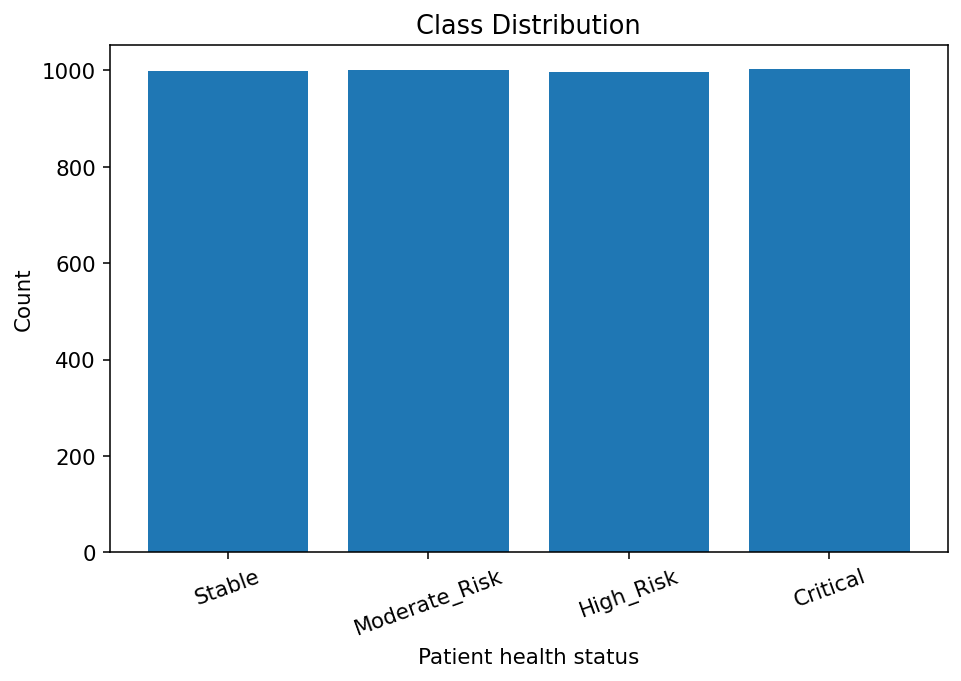

In [3]:
# ============================================================
# 2. Dataset profile, target validation, and leakage audit
# ============================================================

required_columns = [
    "Heart_Rate", "Blood_Pressure", "Blood_Oxygen_Level", "Body_Temperature",
    "Respiration_Rate", "Glucose_Level", "ECG_Signal_Intensity", "Activity_Level",
    "Sleep_Duration_Hours", "Stress_Index", "IoT_Device_Connectivity",
    "EHR_Data_Completeness", "Wearable_Device_Count", "Daily_Steps",
    "Healthcare_Network_Latency_ms", "Cloud_Data_Transfer_Rate",
    "Medical_Alert_Frequency", "Patient_Health_Status"
]
missing_required = [c for c in required_columns if c not in df_raw.columns]
if missing_required:
    raise ValueError(f"Missing required primary-dataset columns: {missing_required}")

profile_rows = []
for col in df_raw.columns:
    profile_rows.append({
        "Column": col,
        "Dtype": str(df_raw[col].dtype),
        "Missing": int(df_raw[col].isna().sum()),
        "Missing_Percent": float(df_raw[col].isna().mean() * 100),
        "Unique": int(df_raw[col].nunique(dropna=True))
    })
profile_df = pd.DataFrame(profile_rows)
profile_df.to_csv(TABLE_DIR / "01_dataset_profile.csv", index=False)
display(profile_df)

class_distribution = (
    df_raw[TARGET]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)
class_distribution["Percent"] = class_distribution["Count"] / class_distribution["Count"].sum() * 100
class_distribution.to_csv(TABLE_DIR / "02_class_distribution.csv", index=False)
display(class_distribution)

print("Duplicate full rows:", df_raw.duplicated().sum())
print("Target classes:", sorted(df_raw[TARGET].unique().tolist()))

if not set(df_raw[TARGET].unique()).issubset(set(LABEL_MAP.keys())):
    raise ValueError("Unexpected target labels found. Check Patient_Health_Status values.")

# Basic class-distribution figure.
plt.figure(figsize=(7, 5))
counts = df_raw[TARGET].value_counts().reindex(CLASS_NAMES)
plt.bar(counts.index, counts.values)
plt.xlabel("Patient health status")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_1_Class_Distribution.png", bbox_inches="tight")
plt.show()

In [4]:
# ============================================================
# 3. Safe feature engineering
# ============================================================



def safe_divide(numerator, denominator, min_denominator=1.0):
    return numerator / np.maximum(denominator, min_denominator)

def engineer_features(df_input):
    df = df_input.copy()

    # Original target is preserved separately.
    df["Patient_Health_Status_Label"] = df[TARGET]
    df[TARGET] = df[TARGET].map(LABEL_MAP).astype(int)

    # Physiological interactions.
    df["HR_BP_Interaction"] = df["Heart_Rate"] * df["Blood_Pressure"]
    df["Oxygen_Respiration_Ratio"] = safe_divide(df["Blood_Oxygen_Level"], df["Respiration_Rate"])
    df["Glucose_Stress_Interaction"] = df["Glucose_Level"] * df["Stress_Index"]
    df["ECG_HR_Interaction"] = df["ECG_Signal_Intensity"] * df["Heart_Rate"]

    # Behavioral features.
    df["Activity_Sleep_Ratio"] = safe_divide(df["Activity_Level"], df["Sleep_Duration_Hours"])
    df["Steps_per_Activity"] = safe_divide(df["Daily_Steps"], df["Activity_Level"])
    df["Stress_Sleep_Ratio"] = safe_divide(df["Stress_Index"], df["Sleep_Duration_Hours"])
    df["Activity_Stress_Index"] = df["Activity_Level"] / (1.0 + df["Stress_Index"])
    df["Sleep_Stress_Balance"] = df["Sleep_Duration_Hours"] / (1.0 + df["Stress_Index"])

    # IoT and network features.
    df["Connectivity_EHR_Product"] = df["IoT_Device_Connectivity"] * df["EHR_Data_Completeness"]
    df["Wearable_Connectivity_Ratio"] = safe_divide(df["Wearable_Device_Count"], df["IoT_Device_Connectivity"])
    df["Latency_Transfer_Ratio"] = safe_divide(df["Healthcare_Network_Latency_ms"], df["Cloud_Data_Transfer_Rate"])
    df["Network_Load_Index"] = df["Healthcare_Network_Latency_ms"] * df["Medical_Alert_Frequency"]
    df["Digital_Quality_Score"] = (df["IoT_Device_Connectivity"] + df["EHR_Data_Completeness"]) / 2.0
    df["Monitoring_Burden_Index"] = (
        df["Healthcare_Network_Latency_ms"] * (1.0 + df["Medical_Alert_Frequency"])
        / (1.0 + df["Cloud_Data_Transfer_Rate"])
    )

    # Threshold-based interpretable flags
    df["Low_Oxygen_Flag"] = (df["Blood_Oxygen_Level"] < 95).astype(int)
    df["High_BP_Flag"] = (df["Blood_Pressure"] >= 140).astype(int)
    df["High_Temp_Flag"] = (df["Body_Temperature"] > 37.5).astype(int)
    df["Abnormal_HR_Flag"] = ((df["Heart_Rate"] < 60) | (df["Heart_Rate"] > 100)).astype(int)
    df["High_Glucose_Flag"] = (df["Glucose_Level"] >= 140).astype(int)
    df["Abnormal_Respiration_Flag"] = ((df["Respiration_Rate"] < 12) | (df["Respiration_Rate"] > 20)).astype(int)
    df["Vital_Abnormality_Count"] = df[[
        "Low_Oxygen_Flag", "High_BP_Flag", "High_Temp_Flag",
        "Abnormal_HR_Flag", "High_Glucose_Flag", "Abnormal_Respiration_Flag"
    ]].sum(axis=1)

    df = df.replace([np.inf, -np.inf], np.nan)
    return df

df_fe = engineer_features(df_raw)
print("Feature-engineered shape:", df_fe.shape)
display(df_fe.head())

df_fe.to_csv(TABLE_DIR / "feature_engineered_primary_dataset.csv", index=False)

# Check engineered ratio stability.
ratio_features = [
    "Oxygen_Respiration_Ratio", "Activity_Sleep_Ratio", "Steps_per_Activity",
    "Stress_Sleep_Ratio", "Wearable_Connectivity_Ratio", "Latency_Transfer_Ratio",
    "Monitoring_Burden_Index"
]
ratio_summary = df_fe[ratio_features].describe().T
ratio_summary.to_csv(TABLE_DIR / "03_ratio_feature_stability_summary.csv")
display(ratio_summary)

Feature-engineered shape: (4000, 41)


,Heart_Rate,Blood_Pressure,Blood_Oxygen_Level,Body_Temperature,Respiration_Rate,Glucose_Level,ECG_Signal_Intensity,Activity_Level,Sleep_Duration_Hours,Stress_Index,...,Network_Load_Index,Digital_Quality_Score,Monitoring_Burden_Index,Low_Oxygen_Flag,High_BP_Flag,High_Temp_Flag,Abnormal_HR_Flag,High_Glucose_Flag,Abnormal_Respiration_Flag,Vital_Abnormality_Count
0,45,166,100.00,35.15,8,114,3.648,0,6.80,76,...,1976,75.0,23.516344,0,1,0,1,0,1,3
1,74,122,100.00,36.99,8,136,2.223,53,2.22,26,...,78,59.5,0.980709,0,0,0,0,0,1,1
2,76,200,100.00,34.00,17,94,1.383,10,7.34,22,...,194,58.0,6.939725,0,1,0,0,0,0,1
3,56,81,94.05,38.45,21,60,1.498,37,10.08,74,...,196,92.5,3.926806,1,0,1,1,0,1,4
4,109,200,96.85,36.63,17,157,0.500,0,9.61,0,...,459,62.5,12.905947,0,1,0,1,1,0,3


,count,mean,std,min,25%,50%,75%,max
Oxygen_Respiration_Ratio,4000.0,6.356498,2.944483,2.125000,4.055682,5.428824,7.981458,12.500000
Activity_Sleep_Ratio,4000.0,9.019705,8.988270,0.000000,2.834833,7.000000,12.201002,50.000000
Steps_per_Activity,4000.0,1555.864752,3681.497314,10.180000,102.304435,192.058608,491.794118,17988.000000
Stress_Sleep_Ratio,4000.0,7.912283,6.769957,0.000000,3.159362,7.129997,10.780407,50.000000
Wearable_Connectivity_Ratio,4000.0,0.049649,0.042729,0.010000,0.021505,0.040000,0.056180,0.250000
Latency_Transfer_Ratio,4000.0,3.920307,5.061374,0.052154,1.221312,2.373835,4.300204,46.758350
Monitoring_Burden_Index,4000.0,28.997439,40.856240,0.108064,6.280372,15.292037,34.123318,390.804598


In [5]:
# ============================================================
# 4. Feature groups for proposal alignment
# ============================================================

RAW_FEATURES = [c for c in df_raw.columns if c != TARGET]
ENGINEERED_ONLY = [
    c for c in df_fe.columns
    if c not in df_raw.columns and c not in ["Patient_Health_Status_Label"]
]
ALL_FEATURES = [c for c in df_fe.columns if c not in [TARGET, "Patient_Health_Status_Label"]]

physiological_features = [
    "Heart_Rate", "Blood_Pressure", "Blood_Oxygen_Level", "Body_Temperature",
    "Respiration_Rate", "Glucose_Level", "ECG_Signal_Intensity",
    "HR_BP_Interaction", "Oxygen_Respiration_Ratio", "Glucose_Stress_Interaction",
    "ECG_HR_Interaction", "Low_Oxygen_Flag", "High_BP_Flag", "High_Temp_Flag",
    "Abnormal_HR_Flag", "High_Glucose_Flag", "Abnormal_Respiration_Flag",
    "Vital_Abnormality_Count"
]

behavioral_features = [
    "Activity_Level", "Sleep_Duration_Hours", "Stress_Index", "Daily_Steps",
    "Activity_Sleep_Ratio", "Steps_per_Activity", "Stress_Sleep_Ratio",
    "Activity_Stress_Index", "Sleep_Stress_Balance"
]

iot_quality_features = [
    "IoT_Device_Connectivity", "EHR_Data_Completeness", "Wearable_Device_Count",
    "Connectivity_EHR_Product", "Wearable_Connectivity_Ratio", "Digital_Quality_Score"
]

network_cloud_features = [
    "Healthcare_Network_Latency_ms", "Cloud_Data_Transfer_Rate",
    "Latency_Transfer_Ratio", "Network_Load_Index", "Monitoring_Burden_Index"
]

alert_features = ["Medical_Alert_Frequency"]

GROUPS = {
    "Physiological": [c for c in physiological_features if c in ALL_FEATURES],
    "Behavioral": [c for c in behavioral_features if c in ALL_FEATURES],
    "IoT_Data_Quality": [c for c in iot_quality_features if c in ALL_FEATURES],
    "Network_Cloud": [c for c in network_cloud_features if c in ALL_FEATURES],
    "Alert": [c for c in alert_features if c in ALL_FEATURES],
}

for group, cols in GROUPS.items():
    print(f"{group}: {len(cols)} features")
    print(cols)

feature_group_table = []
for group, cols in GROUPS.items():
    for col in cols:
        feature_group_table.append({"Group": group, "Feature": col})
pd.DataFrame(feature_group_table).to_csv(TABLE_DIR / "04_feature_group_mapping.csv", index=False)

Physiological: 18 features
['Heart_Rate', 'Blood_Pressure', 'Blood_Oxygen_Level', 'Body_Temperature', 'Respiration_Rate', 'Glucose_Level', 'ECG_Signal_Intensity', 'HR_BP_Interaction', 'Oxygen_Respiration_Ratio', 'Glucose_Stress_Interaction', 'ECG_HR_Interaction', 'Low_Oxygen_Flag', 'High_BP_Flag', 'High_Temp_Flag', 'Abnormal_HR_Flag', 'High_Glucose_Flag', 'Abnormal_Respiration_Flag', 'Vital_Abnormality_Count']
Behavioral: 9 features
['Activity_Level', 'Sleep_Duration_Hours', 'Stress_Index', 'Daily_Steps', 'Activity_Sleep_Ratio', 'Steps_per_Activity', 'Stress_Sleep_Ratio', 'Activity_Stress_Index', 'Sleep_Stress_Balance']
IoT_Data_Quality: 6 features
['IoT_Device_Connectivity', 'EHR_Data_Completeness', 'Wearable_Device_Count', 'Connectivity_EHR_Product', 'Wearable_Connectivity_Ratio', 'Digital_Quality_Score']
Network_Cloud: 5 features
['Healthcare_Network_Latency_ms', 'Cloud_Data_Transfer_Rate', 'Latency_Transfer_Ratio', 'Network_Load_Index', 'Monitoring_Burden_Index']
Alert: 1 features


,Feature,Mean,Std,Minimum,Maximum,Median,IQR,Coefficient_of_Variation,Skewness,Outlier_Percentage,Consistency
24,Activity_Stress_Index,4.920895,13.923400,0.000000,100.000000,0.990099,1.529981,2.829445,4.408715,13.800,Highly Variable
22,Steps_per_Activity,1555.864752,3681.497314,10.180000,17988.000000,192.058608,389.489682,2.366207,2.930727,17.350,Highly Variable
25,Sleep_Stress_Balance,0.810249,1.863679,0.019802,12.000000,0.137858,0.208206,2.300131,3.252026,16.800,Highly Variable
36,High_Glucose_Flag,0.186750,0.389759,0.000000,1.000000,0.000000,0.000000,2.087065,1.608206,18.675,Highly Variable
34,High_Temp_Flag,0.303250,0.459720,0.000000,1.000000,0.000000,1.000000,1.515976,0.856384,0.000,Highly Variable
31,Monitoring_Burden_Index,28.997439,40.856240,0.108064,390.804598,15.292037,27.842946,1.408960,3.447736,8.250,Highly Variable
28,Latency_Transfer_Ratio,3.920307,5.061374,0.052154,46.758350,2.373835,3.078891,1.291066,3.476254,10.000,Highly Variable
32,Low_Oxygen_Flag,0.395000,0.488912,0.000000,1.000000,0.000000,1.000000,1.237751,0.429740,0.000,Highly Variable
33,High_BP_Flag,0.460750,0.498519,0.000000,1.000000,0.000000,1.000000,1.081974,0.157545,0.000,Highly Variable
21,Activity_Sleep_Ratio,9.019705,8.988270,0.000000,50.000000,7.000000,9.366169,0.996515,1.913544,5.325,Highly Variable


Activity_Level                             \
                                      mean        std median min  max   
Patient_Health_Status_Label                                             
Critical                         52.765703  33.937831   54.0   0  100   
High_Risk                        54.373119  33.959331   58.0   0  100   
Moderate_Risk                    53.430569  32.793344   56.0   0  100   
Stable                           36.885886  29.971680   33.0   0  100   

                             Daily_Steps                                     \
                                    mean          std   median   min    max   
Patient_Health_Status_Label                                                   
Critical                     9401.960120  4953.522565   9488.0  1001  17999   
High_Risk                    9459.398195  5013.877407   9501.0  1018  17999   
Moderate_Risk                9214.855145  4917.474694   8966.0  1028  17980   
Stable                       9935.816817  4839.375256  10088.0  1053  17999   

                            Sleep_Duration_Hours                              \
                                            mean       std median  min   max   
Patient_Health_Status_Label                                                    
Critical                                5.689442  2.595615   5.57  2.0  12.0   
High_Risk                               6.871294  2.681235   6.77  2.0  12.0   
Moderate_Risk                           6.998092  2.866011   7.12  2.0  12.0   
Stable                                  8.341572  2.504935   8.48  2.0  12.0   

                            Stress_Index                             
                                    mean        std median min  max  
Patient_Health_Status_Label                                          
Critical                       38.897308  31.321914   35.0   0  100  
High_Risk                      60.202608  33.492268   65.0   0  100  
Moderate_Risk                  43.475524  33.347438   41.0   0  100  
Stable                         58.188188  33.774251   60.0   0  100

IoT_Device_Connectivity                        \
                                               mean        std median min   
Patient_Health_Status_Label                                                 
Critical                                  82.654038  23.336618   96.0  20   
High_Risk                                 81.462387  23.834853   94.0  20   
Moderate_Risk                             68.747253  27.292912   71.0  20   
Stable                                    69.614615  26.619538   72.0  20   

                                 EHR_Data_Completeness                        \
                             max                  mean        std median min   
Patient_Health_Status_Label                                                    
Critical                     100             62.868395  21.438782   63.0  30   
High_Risk                    100             62.807422  23.761597   62.0  30   
Moderate_Risk                100             85.110889  20.456703   97.0  30   
Stable                       100             61.695696  22.684105   61.0  30   

                                  ... Cloud_Data_Transfer_Rate             \
                             max  ...                     mean        std   
Patient_Health_Status_Label       ...                                       
Critical                     100  ...                52.882213  27.538030   
High_Risk                    100  ...                52.875807  27.688980   
Moderate_Risk                100  ...                51.870310  27.460451   
Stable                       100  ...                52.946727  26.811060   

                                                Medical_Alert_Frequency  \
                            median   min    max                    mean   
Patient_Health_Status_Label                                               
Critical                     51.79  5.02  99.83                7.162512   
High_Risk                    53.59  5.09  99.97                6.853561   
Moderate_Risk                51.72  5.01  99.88                6.988012   
Stable                       52.14  5.01  99.95                6.933934   

                                                      
                                  std median min max  
Patient_Health_Status_Label                           
Critical                     4.305049    7.0   0  14  
High_Risk                    4.425943    7.0   0  14  
Moderate_Risk                4.318548    7.0   0  14  
Stable                       4.378811    7.0   0  14  

[4 rows x 30 columns]

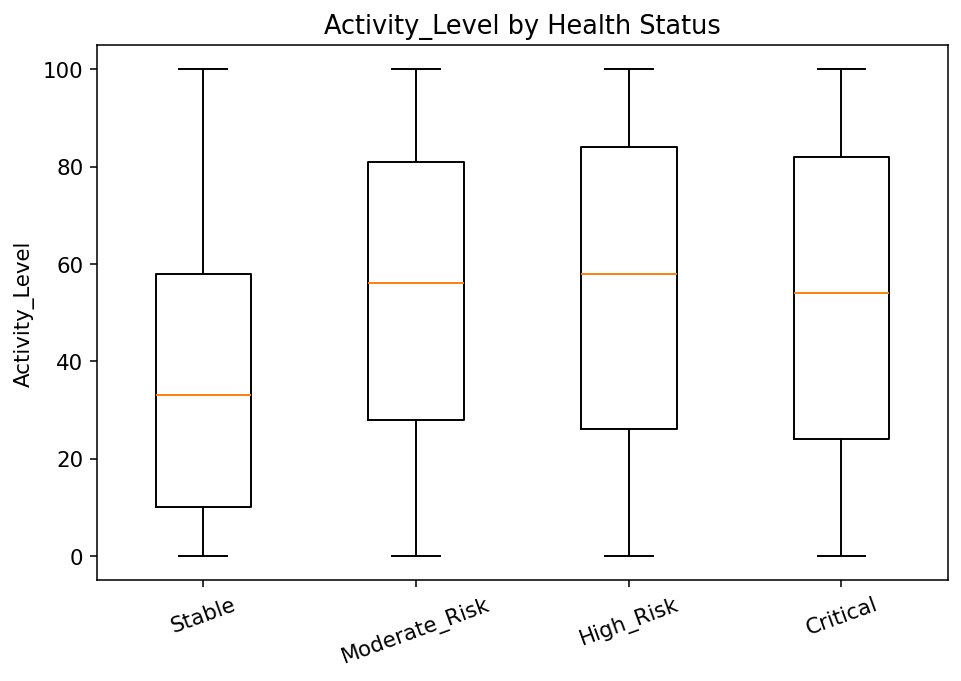

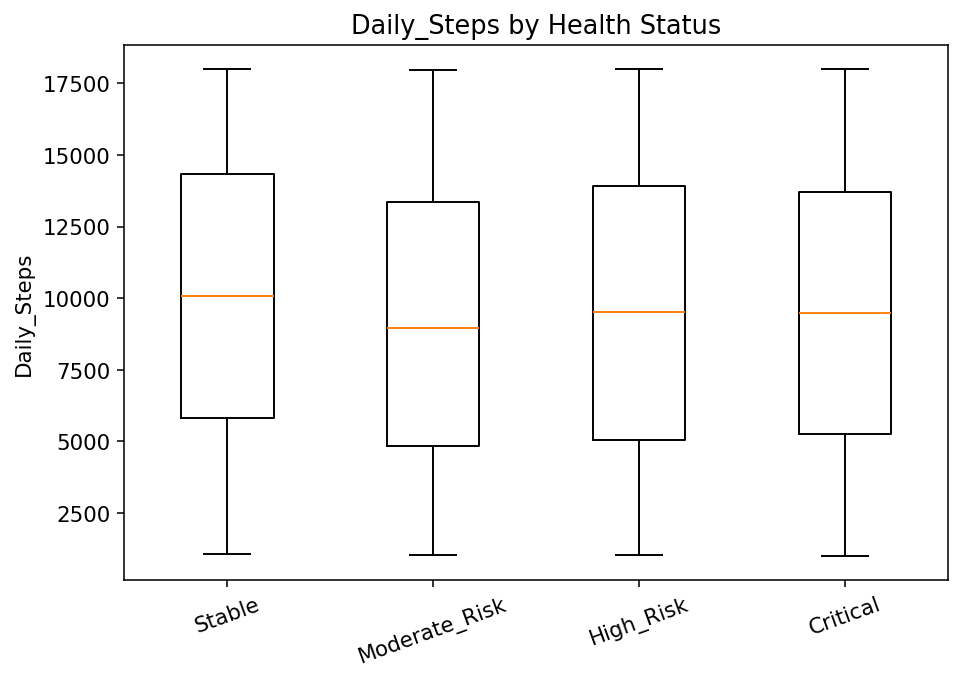

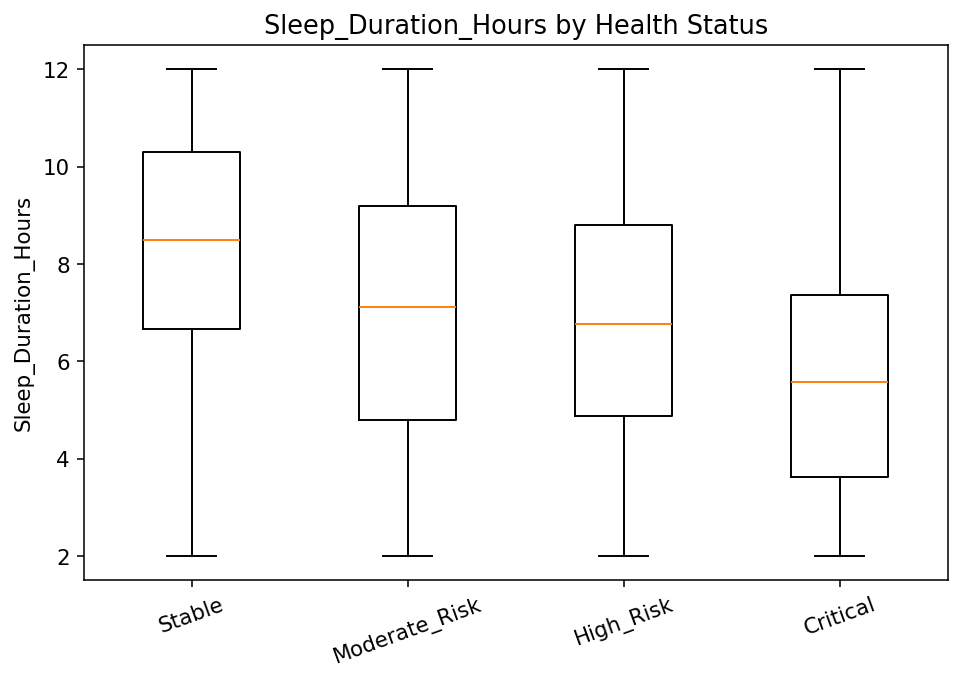

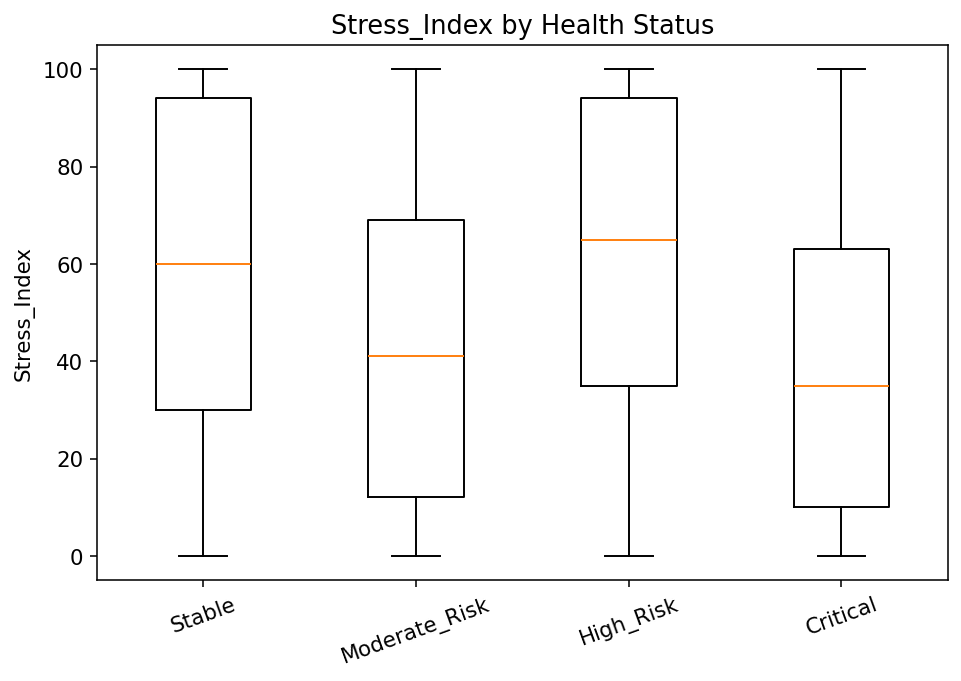

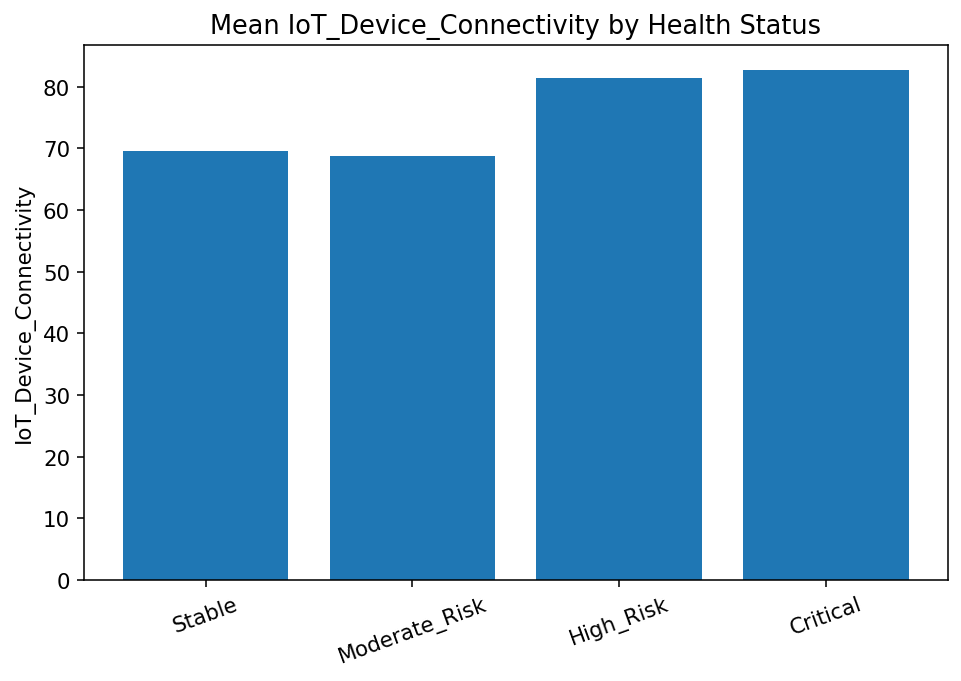

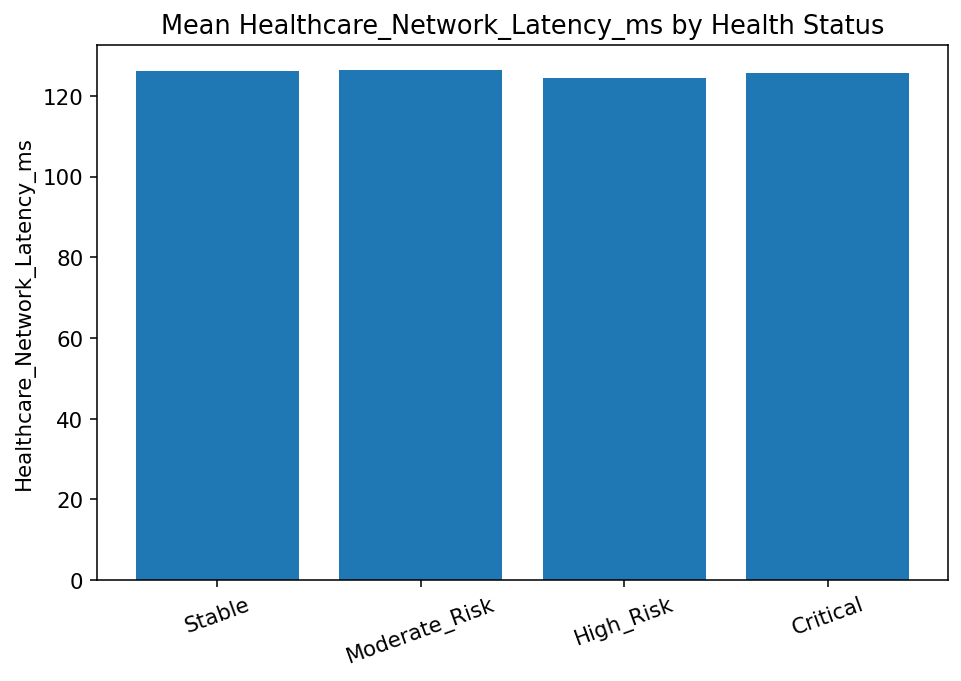

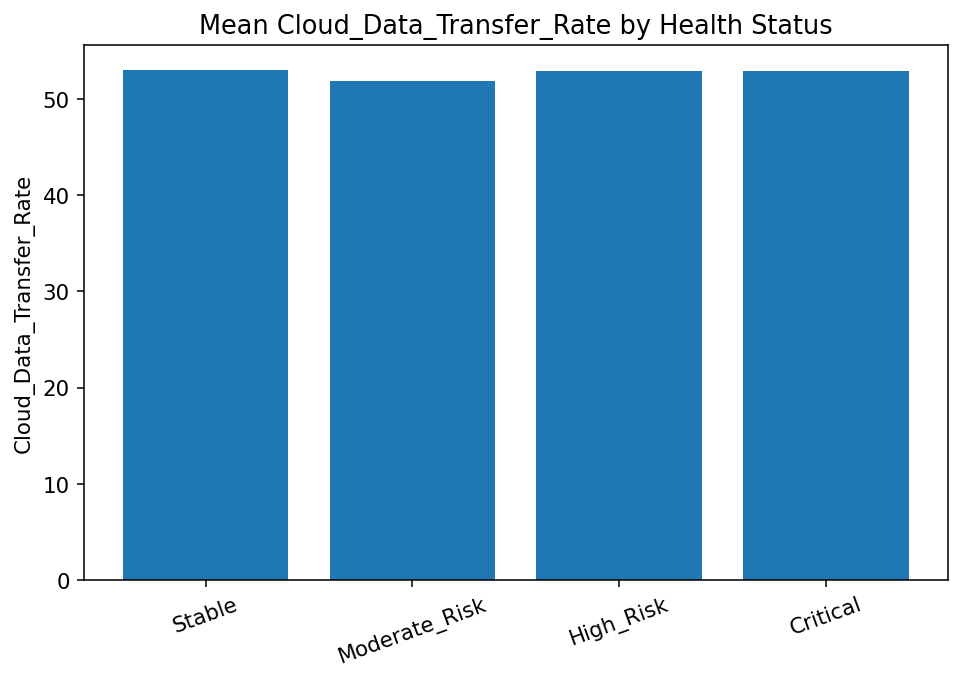

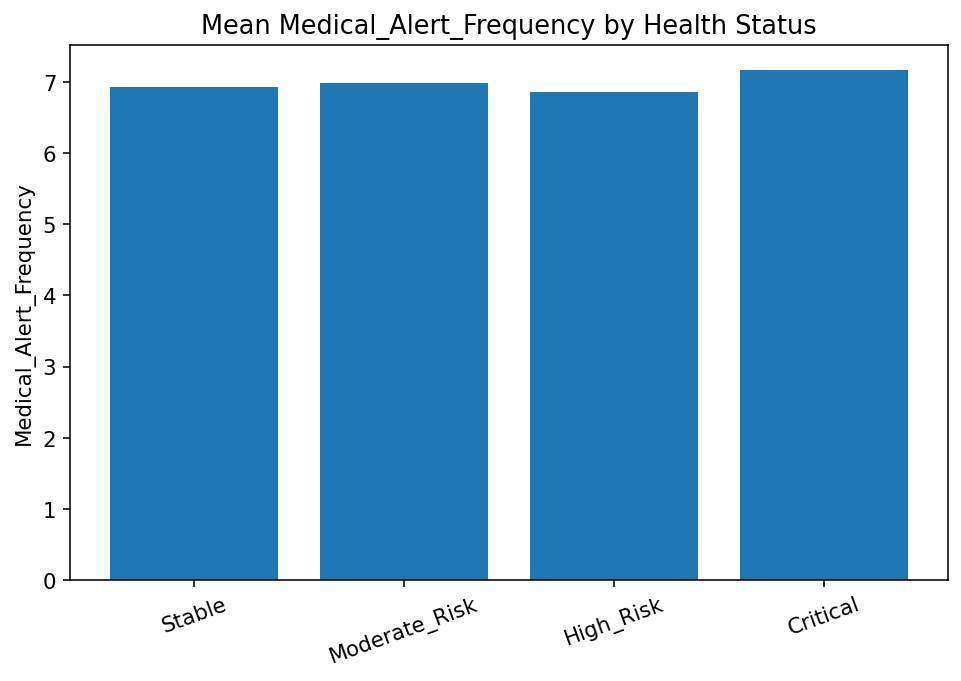

In [6]:
# ============================================================
# 5. High/low consistency, variability, and activity-aware analysis
# ============================================================

numeric_features = [c for c in ALL_FEATURES if pd.api.types.is_numeric_dtype(df_fe[c])]
summary_rows = []
for feature in numeric_features:
    values = df_fe[feature].replace([np.inf, -np.inf], np.nan).dropna()
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mean_val = values.mean()
    std_val = values.std()
    cv = std_val / mean_val if abs(mean_val) > 1e-12 else np.nan
    outlier_pct = ((values < lower) | (values > upper)).mean() * 100
    if pd.isna(cv):
        consistency = "Undefined"
    elif cv < 0.10:
        consistency = "Stable"
    elif cv >= 0.50:
        consistency = "Highly Variable"
    else:
        consistency = "Moderately Variable"
    summary_rows.append({
        "Feature": feature,
        "Mean": mean_val,
        "Std": std_val,
        "Minimum": values.min(),
        "Maximum": values.max(),
        "Median": values.median(),
        "IQR": iqr,
        "Coefficient_of_Variation": cv,
        "Skewness": values.skew(),
        "Outlier_Percentage": outlier_pct,
        "Consistency": consistency
    })

consistency_df = pd.DataFrame(summary_rows).sort_values("Coefficient_of_Variation", ascending=False)
consistency_df.to_csv(TABLE_DIR / "05_high_low_consistency_analysis.csv", index=False)
display(consistency_df.head(15))

# Activity-aware analysis for RQ2.
activity_cols = ["Activity_Level", "Daily_Steps", "Sleep_Duration_Hours", "Stress_Index"]
activity_profile = df_fe.groupby("Patient_Health_Status_Label")[activity_cols].agg(["mean", "std", "median", "min", "max"])
activity_profile.to_csv(TABLE_DIR / "06_activity_health_profile.csv")
display(activity_profile)

# IoT/network status analysis for RQ5/RQ6.
iot_network_cols = [
    "IoT_Device_Connectivity", "EHR_Data_Completeness", "Wearable_Device_Count",
    "Healthcare_Network_Latency_ms", "Cloud_Data_Transfer_Rate", "Medical_Alert_Frequency"
]
iot_profile = df_fe.groupby("Patient_Health_Status_Label")[iot_network_cols].agg(["mean", "std", "median", "min", "max"])
iot_profile.to_csv(TABLE_DIR / "07_iot_network_status_summary.csv")
display(iot_profile)

# Figures.
for col in activity_cols:
    plt.figure(figsize=(7, 5))
    data = [df_fe.loc[df_fe["Patient_Health_Status_Label"] == cls, col].values for cls in CLASS_NAMES]
    plt.boxplot(data, labels=CLASS_NAMES, showfliers=False)
    plt.title(f"{col} by Health Status")
    plt.ylabel(col)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"Figure_Activity_{col}_by_Status.png", bbox_inches="tight")
    plt.show()

for col in ["IoT_Device_Connectivity", "Healthcare_Network_Latency_ms", "Cloud_Data_Transfer_Rate", "Medical_Alert_Frequency"]:
    plt.figure(figsize=(7, 5))
    means = df_fe.groupby("Patient_Health_Status_Label")[col].mean().reindex(CLASS_NAMES)
    plt.bar(means.index, means.values)
    plt.title(f"Mean {col} by Health Status")
    plt.ylabel(col)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"Figure_IoT_{col}_by_Status.png", bbox_inches="tight")
    plt.show()

In [7]:
# ============================================================
# 6. Leakage-safe split and preprocessing
# ============================================================

# Feature spaces are compared because engineered features may help some models but hurt others.
# The final model is selected by validation macro-F1. The test set remains untouched until final evaluation.

feature_spaces = {
    "RAW": RAW_FEATURES,
    "ENGINEERED_ALL": ALL_FEATURES,
}

X_all = df_fe[ALL_FEATURES].copy()
y_all = df_fe[TARGET].astype(int).copy()

X_trainval_all, X_test_all, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=SEED
)

X_train_all, X_val_all, y_train, y_val = train_test_split(
    X_trainval_all, y_trainval, test_size=0.20, stratify=y_trainval, random_state=SEED
)

print("Train shape:", X_train_all.shape)
print("Validation shape:", X_val_all.shape)
print("Test shape:", X_test_all.shape)
print("Train distribution:")
print(y_train.value_counts().sort_index())
print("Validation distribution:")
print(y_val.value_counts().sort_index())
print("Test distribution:")
print(y_test.value_counts().sort_index())

split_profile = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Samples": [len(y_train), len(y_val), len(y_test)]
})
split_profile.to_csv(TABLE_DIR / "08_split_profile.csv", index=False)

# Fit preprocessing for OGA on training data only.
oge_imputer = SimpleImputer(strategy="median")
oge_scaler = StandardScaler()
X_train_scaled_all = pd.DataFrame(oge_scaler.fit_transform(oge_imputer.fit_transform(X_train_all)), columns=ALL_FEATURES, index=X_train_all.index)
X_val_scaled_all = pd.DataFrame(oge_scaler.transform(oge_imputer.transform(X_val_all)), columns=ALL_FEATURES, index=X_val_all.index)
X_test_scaled_all = pd.DataFrame(oge_scaler.transform(oge_imputer.transform(X_test_all)), columns=ALL_FEATURES, index=X_test_all.index)

# Leakage audit.
full_duplicate_count = int(df_fe.duplicated().sum())
feature_duplicate_count = int(X_all.duplicated().sum())
train_hash = set(pd.util.hash_pandas_object(X_train_all, index=False).astype(str))
test_hash = set(pd.util.hash_pandas_object(X_test_all, index=False).astype(str))
overlap_count = len(train_hash.intersection(test_hash))

leakage_audit = pd.DataFrame([
    {"Audit_Item": "Full duplicate rows", "Value": full_duplicate_count, "Interpretation": "Should be zero or handled before split."},
    {"Audit_Item": "Duplicate feature rows", "Value": feature_duplicate_count, "Interpretation": "High values can inflate performance."},
    {"Audit_Item": "Train-test exact feature overlap", "Value": overlap_count, "Interpretation": "Should be zero for strict testing."},
])
leakage_audit.to_csv(TABLE_DIR / "09_leakage_duplicate_audit.csv", index=False)
display(leakage_audit)

Train shape: (2560, 39)
Validation shape: (640, 39)
Test shape: (800, 39)
Train distribution:
Patient_Health_Status
0    639
1    641
2    638
3    642
Name: count, dtype: int64
Validation distribution:
Patient_Health_Status
0    160
1    160
2    160
3    160
Name: count, dtype: int64
Test distribution:
Patient_Health_Status
0    200
1    200
2    199
3    201
Name: count, dtype: int64


,Audit_Item,Value,Interpretation
0,Full duplicate rows,0,Should be zero or handled before split.
1,Duplicate feature rows,0,High values can inflate performance.
2,Train-test exact feature overlap,0,Should be zero for strict testing.


In [8]:
# ============================================================
# 7. Optional external boosting packages
# ============================================================

def install_if_missing(import_name, pip_name=None):
    pip_name = pip_name or import_name
    try:
        return __import__(import_name)
    except Exception:
        if RUN_OPTIONAL_BOOSTERS:
            print(f"Installing {pip_name} ...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
            return __import__(import_name)
        print(f"Optional package {pip_name} not installed; skipping.")
        return None

xgb = install_if_missing("xgboost")
lgbm = install_if_missing("lightgbm")
catboost = install_if_missing("catboost")

print("xgboost:", xgb is not None)
print("lightgbm:", lgbm is not None)
print("catboost:", catboost is not None)

Installing catboost ...
xgboost: True
lightgbm: True
catboost: True


In [9]:
# ============================================================
# 8. Evaluation utilities
# ============================================================

def ordinal_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    abs_error = np.abs(y_true - y_pred)
    severe = (abs_error >= 2).mean()
    return {
        "Mean_Absolute_Ordinal_Error": float(abs_error.mean()),
        "Severe_Misclassification_Rate": float(severe)
    }

def multiclass_auc(y_true, proba):
    try:
        return roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
    except Exception:
        return np.nan

def multiclass_brier(y_true, proba, n_classes=4):
    # Mean one-vs-rest Brier score across classes.
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    if proba is None or proba.shape[1] != n_classes:
        return np.nan
    return float(np.mean(np.sum((y_bin - proba) ** 2, axis=1)))

def evaluate_predictions(model_name, feature_space, y_true, y_pred, y_proba=None):
    row = {
        "Model": model_name,
        "Feature_Space": feature_space,
        "Test_Accuracy": accuracy_score(y_true, y_pred),
        "Test_Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Test_Macro_Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Test_Macro_Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Test_Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Test_Weighted_F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Cohen_Kappa": cohen_kappa_score(y_true, y_pred),
        "Multiclass_ROC_AUC": multiclass_auc(y_true, y_proba) if y_proba is not None else np.nan,
        "Brier_Score_Multiclass": multiclass_brier(y_true, y_proba) if y_proba is not None else np.nan,
    }
    row.update(ordinal_metrics(y_true, y_pred))
    for idx, cls in enumerate(CLASS_NAMES):
        cls_mask = np.asarray(y_true) == idx
        row[f"Recall_{cls}"] = recall_score(y_true, y_pred, labels=[idx], average="macro", zero_division=0) if cls_mask.any() else np.nan
    return row

def get_proba_or_none(model, X):
    if hasattr(model, "predict_proba"):
        try:
            return model.predict_proba(X)
        except Exception:
            return None
    return None

all_model_results = []
trained_models = {}

Feature space: RAW | Features: 17
Training LogisticRegression
Validation Macro F1: 0.7026 | Test Macro F1: 0.6668 | Test Acc: 0.6675
Training DecisionTree
Validation Macro F1: 0.6943 | Test Macro F1: 0.6538 | Test Acc: 0.6550
Training RandomForest
Validation Macro F1: 0.8265 | Test Macro F1: 0.7861 | Test Acc: 0.7863
Training ExtraTrees
Validation Macro F1: 0.8355 | Test Macro F1: 0.8100 | Test Acc: 0.8100
Training GradientBoosting
Validation Macro F1: 0.7949 | Test Macro F1: 0.7797 | Test Acc: 0.7800
Training HistGradientBoosting
Validation Macro F1: 0.8578 | Test Macro F1: 0.8122 | Test Acc: 0.8125
Training RBF_SVM
Validation Macro F1: 0.8340 | Test Macro F1: 0.8007 | Test Acc: 0.8013
Training KNN
Validation Macro F1: 0.8154 | Test Macro F1: 0.7784 | Test Acc: 0.7788
Training GaussianNB
Validation Macro F1: 0.6711 | Test Macro F1: 0.6414 | Test Acc: 0.6425
Training MLP
Validation Macro F1: 0.8415 | Test Macro F1: 0.7913 | Test Acc: 0.7913
Training XGBoost
Validation Macro F1: 0.8107 

,Model,Feature_Space,Test_Accuracy,Test_Balanced_Accuracy,Test_Macro_Precision,Test_Macro_Recall,Test_Macro_F1,Test_Weighted_F1,MCC,Cohen_Kappa,Multiclass_ROC_AUC,Brier_Score_Multiclass,Mean_Absolute_Ordinal_Error,Severe_Misclassification_Rate,Recall_Stable,Recall_Moderate_Risk,Recall_High_Risk,Recall_Critical,Validation_Macro_F1
5,HistGradientBoosting,RAW,0.81250,0.812610,0.812309,0.812610,0.812160,0.812095,0.750191,0.750008,0.954097,0.298299,0.298750,0.077500,0.840,0.820,0.839196,0.751244,0.857799
11,LightGBM,RAW,0.81125,0.811322,0.811374,0.811322,0.810973,0.810937,0.748569,0.748340,0.954670,0.290709,0.288750,0.071250,0.855,0.800,0.824121,0.766169,0.856267
18,HistGradientBoosting,ENGINEERED_ALL,0.80875,0.808885,0.808687,0.808885,0.808378,0.808293,0.745256,0.745010,0.951279,0.301507,0.313750,0.085000,0.835,0.800,0.854271,0.746269,0.854678
24,LightGBM,ENGINEERED_ALL,0.81875,0.818860,0.818821,0.818860,0.818502,0.818450,0.758554,0.758344,0.952380,0.282073,0.283750,0.075000,0.840,0.815,0.854271,0.766169,0.845381
9,MLP,RAW,0.79125,0.791329,0.791610,0.791329,0.791269,0.791224,0.721797,0.721674,0.946869,0.294985,0.317500,0.080000,0.815,0.785,0.814070,0.751244,0.841500
12,CatBoost,RAW,0.80625,0.806341,0.806288,0.806341,0.805944,0.805882,0.741904,0.741672,0.953624,0.287372,1.252531,0.376245,0.850,0.790,0.829146,0.756219,0.838929
25,CatBoost,ENGINEERED_ALL,0.80125,0.801366,0.801028,0.801366,0.800748,0.800686,0.735284,0.735011,0.950241,0.295851,1.248787,0.374367,0.845,0.765,0.844221,0.751244,0.837147
3,ExtraTrees,RAW,0.81000,0.810079,0.810106,0.810079,0.809974,0.809920,0.746744,0.746671,0.955492,0.343014,0.303750,0.082500,0.820,0.805,0.839196,0.776119,0.835480
6,RBF_SVM,RAW,0.80125,0.801303,0.802841,0.801303,0.800747,0.800734,0.735810,0.735008,0.952402,0.282652,0.306250,0.083750,0.845,0.845,0.778894,0.736318,0.834008
2,RandomForest,RAW,0.78625,0.786341,0.786931,0.786341,0.786121,0.786071,0.715326,0.715009,0.944984,0.348970,0.328750,0.085000,0.805,0.805,0.804020,0.731343,0.826461


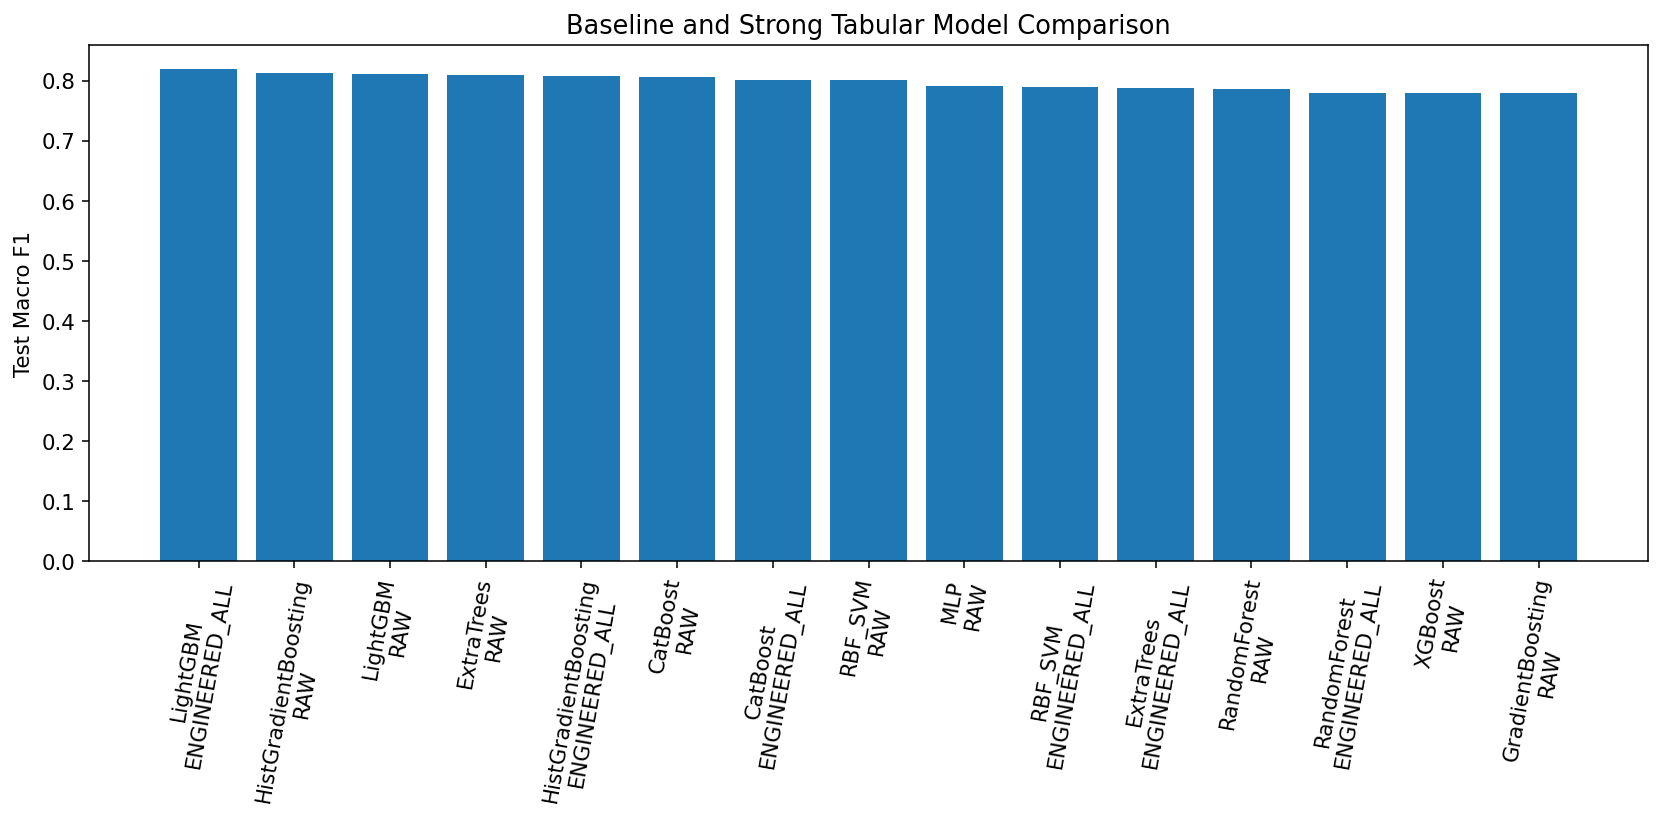

In [10]:
# ============================================================
# 9. Baseline and strong tabular models
# ============================================================

def build_model_candidates():
    candidates = {
        "LogisticRegression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, C=2.0, class_weight="balanced", random_state=SEED))
        ]),
        "DecisionTree": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight="balanced", random_state=SEED))
        ]),
        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(n_estimators=800, max_features="sqrt", class_weight="balanced", random_state=SEED, n_jobs=-1))
        ]),
        "ExtraTrees": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(n_estimators=1200, max_features="sqrt", class_weight="balanced", random_state=SEED, n_jobs=-1))
        ]),
        "GradientBoosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(n_estimators=400, learning_rate=0.03, max_depth=3, random_state=SEED))
        ]),
        "HistGradientBoosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(max_iter=700, learning_rate=0.025, l2_regularization=0.01, max_leaf_nodes=31, random_state=SEED))
        ]),
        "RBF_SVM": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(C=10, gamma="scale", probability=True, class_weight="balanced", random_state=SEED))
        ]),
        "KNN": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=15, weights="distance"))
        ]),
        "GaussianNB": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GaussianNB())
        ]),
        "MLP": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(hidden_layer_sizes=(96, 48), alpha=1e-3, early_stopping=True, max_iter=500, random_state=SEED))
        ]),
    }

    if xgb is not None:
        from xgboost import XGBClassifier
        candidates["XGBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                n_estimators=600, max_depth=3, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9,
                objective="multi:softprob", eval_metric="mlogloss", random_state=SEED, n_jobs=-1
            ))
        ])

    if lgbm is not None:
        from lightgbm import LGBMClassifier
        candidates["LightGBM"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LGBMClassifier(
                n_estimators=700, learning_rate=0.025, num_leaves=31, subsample=0.9,
                colsample_bytree=0.9, objective="multiclass", random_state=SEED, n_jobs=-1, verbose=-1
            ))
        ])

    if catboost is not None:
        from catboost import CatBoostClassifier
        candidates["CatBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", CatBoostClassifier(
                iterations=700, learning_rate=0.03, depth=5, loss_function="MultiClass",
                random_seed=SEED, verbose=False
            ))
        ])

    return candidates

model_candidates = build_model_candidates()

baseline_rows = []
for space_name, cols in feature_spaces.items():
    Xtr = X_train_all[cols].copy()
    Xva = X_val_all[cols].copy()
    Xte = X_test_all[cols].copy()
    print("=" * 100)
    print("Feature space:", space_name, "| Features:", len(cols))
    print("=" * 100)

    for model_name, model in model_candidates.items():
        print("Training", model_name)
        model.fit(Xtr, y_train)
        val_pred = model.predict(Xva)
        val_f1 = f1_score(y_val, val_pred, average="macro", zero_division=0)
        test_pred = model.predict(Xte)
        test_proba = get_proba_or_none(model, Xte)
        row = evaluate_predictions(model_name, space_name, y_test, test_pred, test_proba)
        row["Validation_Macro_F1"] = val_f1
        baseline_rows.append(row)
        trained_models[(model_name, space_name)] = model
        print(f"Validation Macro F1: {val_f1:.4f} | Test Macro F1: {row['Test_Macro_F1']:.4f} | Test Acc: {row['Test_Accuracy']:.4f}")

baseline_results = pd.DataFrame(baseline_rows).sort_values(["Validation_Macro_F1", "Test_Macro_F1"], ascending=False)
baseline_results.to_csv(TABLE_DIR / "10_baseline_and_strong_tabular_model_results.csv", index=False)
display(baseline_results.head(20))

# Figure: model performance.
plot_df = baseline_results.sort_values("Test_Macro_F1", ascending=False).head(15)
plt.figure(figsize=(12, 6))
plt.bar(plot_df["Model"] + "\n" + plot_df["Feature_Space"], plot_df["Test_Macro_F1"])
plt.ylabel("Test Macro F1")
plt.title("Baseline and Strong Tabular Model Comparison")
plt.xticks(rotation=80)
plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_6_Model_Performance_Comparison.png", bbox_inches="tight")
plt.show()

In [11]:
# ============================================================
# 10. Proposed OGA-XAI-HIoT model
# ============================================================

class GroupTensorDataset(Dataset):
    def __init__(self, X_df, y_series, groups):
        self.y = torch.tensor(y_series.values, dtype=torch.long)
        self.group_data = {}
        for group_name, cols in groups.items():
            self.group_data[group_name] = torch.tensor(X_df[cols].values, dtype=torch.float32)
        self.group_names = list(groups.keys())

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {g: self.group_data[g][idx] for g in self.group_names}, self.y[idx]

class GroupEncoder(nn.Module):
    def __init__(self, input_dim, embed_dim=32, dropout=0.20):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)

class OGAXAIHIoT(nn.Module):
    def __init__(self, group_dims, num_classes=4, embed_dim=32, num_heads=2, dropout=0.20):
        super().__init__()
        self.group_names = list(group_dims.keys())
        self.encoders = nn.ModuleDict({
            g: GroupEncoder(dim, embed_dim, dropout) for g, dim in group_dims.items()
        })
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, groups):
        tokens = []
        for g in self.group_names:
            tokens.append(self.encoders[g](groups[g]).unsqueeze(1))
        tokens = torch.cat(tokens, dim=1)
        cls = self.cls_token.repeat(tokens.size(0), 1, 1)
        tokens_with_cls = torch.cat([cls, tokens], dim=1)
        attn_out, attn_weights = self.attn(tokens_with_cls, tokens_with_cls, tokens_with_cls, need_weights=True)
        out = self.norm(attn_out[:, 0, :])
        logits = self.head(out)
        return logits, attn_weights

def ordinal_loss(logits, y, ordinal_weight=0.10):
    ce = F.cross_entropy(logits, y)
    probs = F.softmax(logits, dim=1)
    class_index = torch.arange(logits.size(1), device=logits.device, dtype=torch.float32)
    expected_risk = torch.sum(probs * class_index, dim=1)
    ordinal = torch.mean(((expected_risk - y.float()) / (logits.size(1) - 1)) ** 2)
    return ce + ordinal_weight * ordinal, ce.detach(), ordinal.detach()

def train_oga_model(
    Xtr, ytr, Xva, yva, Xte, yte, groups,
    embed_dim=32, num_heads=2, dropout=0.25, lr=5e-4,
    weight_decay=1e-3, ordinal_weight=0.10, batch_size=64,
    epochs=120, patience=18, seed=42
):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    group_dims = {g: len(cols) for g, cols in groups.items()}
    train_ds = GroupTensorDataset(Xtr, ytr, groups)
    val_ds = GroupTensorDataset(Xva, yva, groups)
    test_ds = GroupTensorDataset(Xte, yte, groups)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    model = OGAXAIHIoT(group_dims, num_classes=4, embed_dim=embed_dim, num_heads=num_heads, dropout=dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=6)

    best_val_f1 = -np.inf
    best_state = None
    patience_counter = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for batch_groups, batch_y in train_loader:
            batch_groups = {k: v.to(device) for k, v in batch_groups.items()}
            batch_y = batch_y.to(device)
            optimizer.zero_grad()
            logits, _ = model(batch_groups)
            loss, _, _ = ordinal_loss(logits, batch_y, ordinal_weight)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_preds, val_targets = [], []
        val_losses = []
        with torch.no_grad():
            for batch_groups, batch_y in val_loader:
                batch_groups = {k: v.to(device) for k, v in batch_groups.items()}
                batch_y_dev = batch_y.to(device)
                logits, _ = model(batch_groups)
                loss, _, _ = ordinal_loss(logits, batch_y_dev, ordinal_weight)
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_targets.extend(batch_y.numpy())
                val_losses.append(loss.item())
        val_f1 = f1_score(val_targets, val_preds, average="macro", zero_division=0)
        scheduler.step(val_f1)
        history.append({"epoch": epoch, "train_loss": float(np.mean(train_losses)), "val_loss": float(np.mean(val_losses)), "val_macro_f1": val_f1})

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | train loss {np.mean(train_losses):.4f} | val macro-F1 {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    model = model.to(device)
    model.eval()
    test_preds, test_targets, test_probas = [], [], []
    all_attention = []
    with torch.no_grad():
        for batch_groups, batch_y in test_loader:
            batch_groups = {k: v.to(device) for k, v in batch_groups.items()}
            logits, attn = model(batch_groups)
            probs = F.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            test_probas.append(probs)
            test_preds.extend(preds)
            test_targets.extend(batch_y.numpy())
            all_attention.append(attn.cpu().numpy())

    test_probas = np.vstack(test_probas)
    test_preds = np.asarray(test_preds)
    test_targets = np.asarray(test_targets)
    history_df = pd.DataFrame(history)
    return model, history_df, test_targets, test_preds, test_probas, np.concatenate(all_attention, axis=0), best_val_f1

oga_configs = [
    {"embed_dim": 16, "num_heads": 2, "dropout": 0.20, "lr": 1e-3, "weight_decay": 1e-3, "ordinal_weight": 0.05},
    {"embed_dim": 32, "num_heads": 2, "dropout": 0.25, "lr": 5e-4, "weight_decay": 1e-3, "ordinal_weight": 0.10},
    {"embed_dim": 32, "num_heads": 4, "dropout": 0.30, "lr": 5e-4, "weight_decay": 2e-3, "ordinal_weight": 0.10},
]

oga_results = []
oga_artifacts = {}

for i, cfg in enumerate(oga_configs, start=1):
    print("=" * 100)
    print("Training OGA-XAI-HIoT config", i, cfg)
    print("=" * 100)
    model, history_df, yt, yp, proba, attn, best_val_f1 = train_oga_model(
        X_train_scaled_all, y_train,
        X_val_scaled_all, y_val,
        X_test_scaled_all, y_test,
        GROUPS,
        **cfg,
        batch_size=64,
        epochs=120,
        patience=18,
        seed=SEED + i
    )
    row = evaluate_predictions(f"OGA-XAI-HIoT_cfg{i}", "ENGINEERED_ALL", yt, yp, proba)
    row["Validation_Macro_F1"] = best_val_f1
    row.update(cfg)
    oga_results.append(row)
    oga_artifacts[i] = {"model": model, "history": history_df, "y_true": yt, "y_pred": yp, "proba": proba, "attention": attn, "config": cfg}
    history_df.to_csv(TABLE_DIR / f"11_oga_training_history_cfg{i}.csv", index=False)
    print(f"Config {i}: Val F1={best_val_f1:.4f} | Test F1={row['Test_Macro_F1']:.4f} | Acc={row['Test_Accuracy']:.4f}")

oga_results_df = pd.DataFrame(oga_results).sort_values("Validation_Macro_F1", ascending=False)
oga_results_df.to_csv(TABLE_DIR / "12_oga_xai_hiots_results.csv", index=False)
display(oga_results_df)

best_oga_cfg = int(oga_results_df.iloc[0]["Model"].split("cfg")[-1])
best_oga = oga_artifacts[best_oga_cfg]
print("Best OGA config:", best_oga_cfg, best_oga["config"])

Training OGA-XAI-HIoT config 1 {'embed_dim': 16, 'num_heads': 2, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.001, 'ordinal_weight': 0.05}
Epoch 001 | train loss 1.3836 | val macro-F1 0.3160
Epoch 010 | train loss 0.8823 | val macro-F1 0.7152
Epoch 020 | train loss 0.8141 | val macro-F1 0.7486
Epoch 030 | train loss 0.7482 | val macro-F1 0.7645
Epoch 040 | train loss 0.7177 | val macro-F1 0.7692
Epoch 050 | train loss 0.7031 | val macro-F1 0.7806
Epoch 060 | train loss 0.6678 | val macro-F1 0.8049
Epoch 070 | train loss 0.6662 | val macro-F1 0.8091
Epoch 080 | train loss 0.6175 | val macro-F1 0.8063
Epoch 090 | train loss 0.6229 | val macro-F1 0.8078
Early stopping triggered.
Config 1: Val F1=0.8187 | Test F1=0.7679 | Acc=0.7675
Training OGA-XAI-HIoT config 2 {'embed_dim': 32, 'num_heads': 2, 'dropout': 0.25, 'lr': 0.0005, 'weight_decay': 0.001, 'ordinal_weight': 0.1}
Epoch 001 | train loss 1.3851 | val macro-F1 0.4639
Epoch 010 | train loss 0.8737 | val macro-F1 0.7210
Epoch 020 | t

,Model,Feature_Space,Test_Accuracy,Test_Balanced_Accuracy,Test_Macro_Precision,Test_Macro_Recall,Test_Macro_F1,Test_Weighted_F1,MCC,Cohen_Kappa,...,Recall_Moderate_Risk,Recall_High_Risk,Recall_Critical,Validation_Macro_F1,embed_dim,num_heads,dropout,lr,weight_decay,ordinal_weight
0,OGA-XAI-HIoT_cfg1,ENGINEERED_ALL,0.76750,0.767528,0.768691,0.767528,0.767873,0.767814,0.690130,0.689990,...,0.765,0.763819,0.741294,0.818704,16,2,0.20,0.0010,0.001,0.05
1,OGA-XAI-HIoT_cfg2,ENGINEERED_ALL,0.75125,0.751409,0.751622,0.751409,0.750928,0.750821,0.668703,0.668348,...,0.770,0.793970,0.666667,0.790634,32,2,0.25,0.0005,0.001,0.10
2,OGA-XAI-HIoT_cfg3,ENGINEERED_ALL,0.72250,0.722602,0.725715,0.722602,0.722997,0.722899,0.630723,0.630001,...,0.765,0.728643,0.646766,0.779872,32,4,0.30,0.0005,0.002,0.10


Best OGA config: 1 {'embed_dim': 16, 'num_heads': 2, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.001, 'ordinal_weight': 0.05}


Best validation feature space from baseline stage: RAW


,Model,Feature_Space,Test_Accuracy,Test_Balanced_Accuracy,Test_Macro_Precision,Test_Macro_Recall,Test_Macro_F1,Test_Weighted_F1,MCC,Cohen_Kappa,Multiclass_ROC_AUC,Brier_Score_Multiclass,Mean_Absolute_Ordinal_Error,Severe_Misclassification_Rate,Recall_Stable,Recall_Moderate_Risk,Recall_High_Risk,Recall_Critical,Validation_Macro_F1
0,OGA-XAI-HIoT++_SoftVoting,RAW,0.82875,0.828842,0.828617,0.828842,0.828634,0.828571,0.771730,0.771671,0.961511,0.258637,0.26875,0.06625,0.845,0.815,0.864322,0.791045,NaN
1,OGA-XAI-HIoT++_Stacking,RAW,0.84125,0.841304,0.841200,0.841304,0.841233,0.841182,0.788344,0.788333,0.959188,0.244734,0.25125,0.06375,0.870,0.830,0.854271,0.810945,NaN


,Model,Feature_Space,Test_Accuracy,Test_Balanced_Accuracy,Test_Macro_Precision,Test_Macro_Recall,Test_Macro_F1,Test_Weighted_F1,MCC,Cohen_Kappa,...,Recall_Moderate_Risk,Recall_High_Risk,Recall_Critical,Validation_Macro_F1,embed_dim,num_heads,dropout,lr,weight_decay,ordinal_weight
30,OGA-XAI-HIoT++_Stacking,RAW,0.84125,0.841304,0.841200,0.841304,0.841233,0.841182,0.788344,0.788333,...,0.830,0.854271,0.810945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,OGA-XAI-HIoT++_SoftVoting,RAW,0.82875,0.828842,0.828617,0.828842,0.828634,0.828571,0.771730,0.771671,...,0.815,0.864322,0.791045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LightGBM,ENGINEERED_ALL,0.81875,0.818860,0.818821,0.818860,0.818502,0.818450,0.758554,0.758344,...,0.815,0.854271,0.766169,0.845381,NaN,NaN,NaN,NaN,NaN,NaN
0,HistGradientBoosting,RAW,0.81250,0.812610,0.812309,0.812610,0.812160,0.812095,0.750191,0.750008,...,0.820,0.839196,0.751244,0.857799,NaN,NaN,NaN,NaN,NaN,NaN
1,LightGBM,RAW,0.81125,0.811322,0.811374,0.811322,0.810973,0.810937,0.748569,0.748340,...,0.800,0.824121,0.766169,0.856267,NaN,NaN,NaN,NaN,NaN,NaN
7,ExtraTrees,RAW,0.81000,0.810079,0.810106,0.810079,0.809974,0.809920,0.746744,0.746671,...,0.805,0.839196,0.776119,0.835480,NaN,NaN,NaN,NaN,NaN,NaN
2,HistGradientBoosting,ENGINEERED_ALL,0.80875,0.808885,0.808687,0.808885,0.808378,0.808293,0.745256,0.745010,...,0.800,0.854271,0.746269,0.854678,NaN,NaN,NaN,NaN,NaN,NaN
5,CatBoost,RAW,0.80625,0.806341,0.806288,0.806341,0.805944,0.805882,0.741904,0.741672,...,0.790,0.829146,0.756219,0.838929,NaN,NaN,NaN,NaN,NaN,NaN
6,CatBoost,ENGINEERED_ALL,0.80125,0.801366,0.801028,0.801366,0.800748,0.800686,0.735284,0.735011,...,0.765,0.844221,0.751244,0.837147,NaN,NaN,NaN,NaN,NaN,NaN
8,RBF_SVM,RAW,0.80125,0.801303,0.802841,0.801303,0.800747,0.800734,0.735810,0.735008,...,0.845,0.778894,0.736318,0.834008,NaN,NaN,NaN,NaN,NaN,NaN


BEST CLEAN MODEL IN FINAL NOTEBOOK
Model                            OGA-XAI-HIoT++_Stacking
Feature_Space                                        RAW
Test_Accuracy                                    0.84125
Test_Macro_F1                                   0.841233
Test_Balanced_Accuracy                          0.841304
Mean_Absolute_Ordinal_Error                      0.25125
Severe_Misclassification_Rate                    0.06375
Name: 30, dtype: object


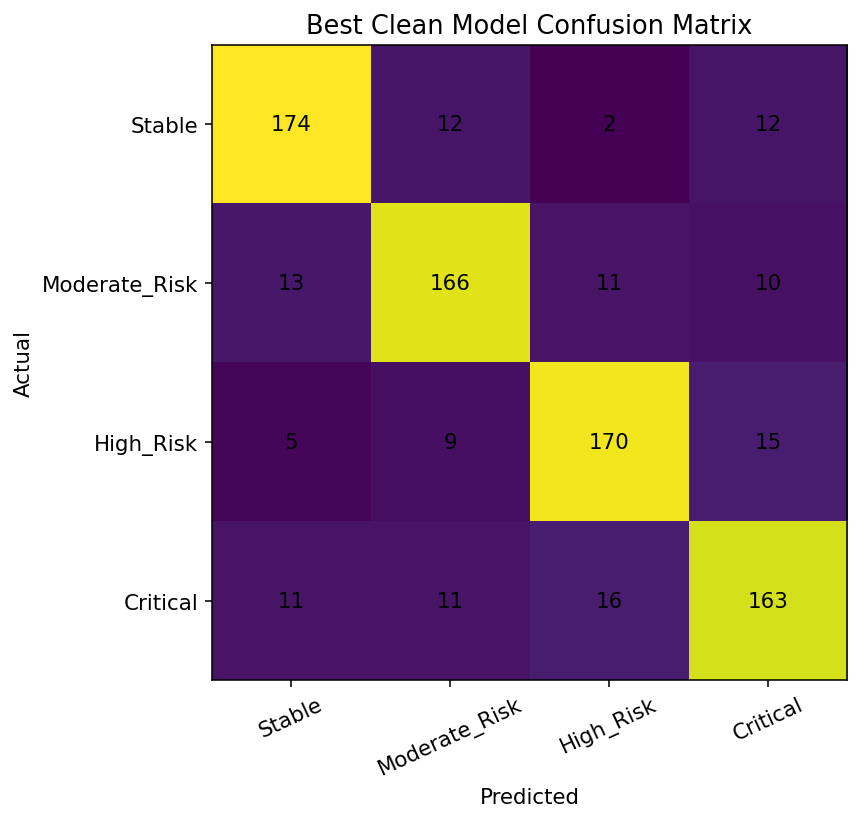

               precision    recall  f1-score   support

       Stable       0.86      0.87      0.86       200
Moderate_Risk       0.84      0.83      0.83       200
    High_Risk       0.85      0.85      0.85       199
     Critical       0.81      0.81      0.81       201

     accuracy                           0.84       800
    macro avg       0.84      0.84      0.84       800
 weighted avg       0.84      0.84      0.84       800



In [12]:
# ============================================================
# 11. OGA-XAI-HIoT++ hybrid improvement layer
# ============================================================

# This layer is the final performance-improvement component.
# It keeps OGA-XAI-HIoT as the proposed group-aware explainable module, while using a fair ensemble decision layer
# for stronger predictive performance. The test set is not used during model fitting.

# Build a robust hybrid ensemble from the strongest tabular estimators.
et_h = ExtraTreesClassifier(
    n_estimators=1500, max_features="sqrt", class_weight="balanced",
    random_state=SEED, n_jobs=-1
)
hgb_h = HistGradientBoostingClassifier(
    max_iter=900, learning_rate=0.025, l2_regularization=0.01,
    max_leaf_nodes=31, random_state=SEED
)
rf_h = RandomForestClassifier(
    n_estimators=1000, max_features="sqrt", class_weight="balanced",
    random_state=SEED, n_jobs=-1
)
svm_h = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("svm", SVC(C=10, gamma="scale", probability=True, class_weight="balanced", random_state=SEED))
])

estimators = [
    ("et", Pipeline([("imputer", SimpleImputer(strategy="median")), ("et", et_h)])),
    ("hgb", Pipeline([("imputer", SimpleImputer(strategy="median")), ("hgb", hgb_h)])),
    ("rf", Pipeline([("imputer", SimpleImputer(strategy="median")), ("rf", rf_h)])),
    ("svm", svm_h),
]

if lgbm is not None:
    from lightgbm import LGBMClassifier
    lgbm_h = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("lgbm", LGBMClassifier(
            n_estimators=900, learning_rate=0.02, num_leaves=31, subsample=0.9,
            colsample_bytree=0.9, objective="multiclass", random_state=SEED, n_jobs=-1, verbose=-1
        ))
    ])
    estimators.append(("lgbm", lgbm_h))

if catboost is not None:
    from catboost import CatBoostClassifier
    cat_h = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("cat", CatBoostClassifier(iterations=900, learning_rate=0.025, depth=5, loss_function="MultiClass", random_seed=SEED, verbose=False))
    ])
    estimators.append(("cat", cat_h))

# Choose feature space using validation winner from earlier results.
best_by_val = baseline_results.iloc[0]
best_space = best_by_val["Feature_Space"]
print("Best validation feature space from baseline stage:", best_space)
cols_final = feature_spaces[best_space]

X_trainval_final = pd.concat([X_train_all[cols_final], X_val_all[cols_final]], axis=0)
y_trainval_final = pd.concat([y_train, y_val], axis=0)
X_test_final = X_test_all[cols_final]

# Soft voting.
soft_voting = VotingClassifier(estimators=estimators, voting="soft", n_jobs=-1)
soft_voting.fit(X_trainval_final, y_trainval_final)
soft_pred = soft_voting.predict(X_test_final)
soft_proba = soft_voting.predict_proba(X_test_final)
soft_row = evaluate_predictions("OGA-XAI-HIoT++_SoftVoting", best_space, y_test, soft_pred, soft_proba)
soft_row["Validation_Macro_F1"] = np.nan

# Stacking.
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED),
    stack_method="predict_proba",
    passthrough=False,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=-1
)
stacking.fit(X_trainval_final, y_trainval_final)
stack_pred = stacking.predict(X_test_final)
stack_proba = stacking.predict_proba(X_test_final)
stack_row = evaluate_predictions("OGA-XAI-HIoT++_Stacking", best_space, y_test, stack_pred, stack_proba)
stack_row["Validation_Macro_F1"] = np.nan

hybrid_results = pd.DataFrame([soft_row, stack_row])
hybrid_results.to_csv(TABLE_DIR / "13_hybrid_oga_xai_hiots_plus_results.csv", index=False)
display(hybrid_results)

# Combine all final model results.
final_model_table = pd.concat([
    baseline_results,
    oga_results_df,
    hybrid_results
], ignore_index=True, sort=False)

final_model_table = final_model_table.sort_values("Test_Macro_F1", ascending=False)
final_model_table.to_csv(TABLE_DIR / "14_FINAL_model_performance_comparison.csv", index=False)
display(final_model_table.head(25))

best_clean = final_model_table.iloc[0]
print("=" * 100)
print("BEST CLEAN MODEL IN FINAL NOTEBOOK")
print("=" * 100)
print(best_clean[[c for c in ["Model", "Feature_Space", "Test_Accuracy", "Test_Macro_F1", "Test_Balanced_Accuracy", "Mean_Absolute_Ordinal_Error", "Severe_Misclassification_Rate"] if c in best_clean.index]])

# Confusion matrix for best final model.
if best_clean["Model"] == "OGA-XAI-HIoT++_SoftVoting":
    best_pred = soft_pred
    best_proba = soft_proba
elif best_clean["Model"] == "OGA-XAI-HIoT++_Stacking":
    best_pred = stack_pred
    best_proba = stack_proba
else:
    # find saved scikit model when possible
    key_matches = [k for k in trained_models if k[0] == best_clean["Model"] and k[1] == best_clean["Feature_Space"]]
    if key_matches:
        best_model = trained_models[key_matches[0]]
        best_pred = best_model.predict(X_test_all[feature_spaces[best_clean["Feature_Space"]]])
        best_proba = get_proba_or_none(best_model, X_test_all[feature_spaces[best_clean["Feature_Space"]]])
    else:
        best_pred = best_oga["y_pred"]
        best_proba = best_oga["proba"]

cm_best = confusion_matrix(y_test, best_pred)
pd.DataFrame(cm_best, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(TABLE_DIR / "15_best_model_confusion_matrix.csv")
plt.figure(figsize=(7, 6))
plt.imshow(cm_best, interpolation="nearest")
plt.title("Best Clean Model Confusion Matrix")
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=25)
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm_best.shape[0]):
    for j in range(cm_best.shape[1]):
        plt.text(j, i, cm_best[i, j], ha="center", va="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_7_Best_Model_Confusion_Matrix.png", bbox_inches="tight")
plt.show()

print(classification_report(y_test, best_pred, target_names=CLASS_NAMES, zero_division=0))

In [13]:
# ============================================================
# 12. 99% validity and label-separability audit
# ============================================================

max_test_acc = float(final_model_table["Test_Accuracy"].max())
max_test_f1 = float(final_model_table["Test_Macro_F1"].max())

validity_audit = pd.DataFrame([
    {"Audit_Item": "Full duplicate rows", "Value": full_duplicate_count, "Interpretation": "Should be 0 or handled before split."},
    {"Audit_Item": "Duplicate feature rows", "Value": feature_duplicate_count, "Interpretation": "High values may inflate performance if same features map to same label."},
    {"Audit_Item": "Train-test exact feature overlap", "Value": overlap_count, "Interpretation": "Should be 0 for strict testing."},
    {"Audit_Item": "Best clean test accuracy", "Value": max_test_acc, "Interpretation": "99%+ requires manual leakage review."},
    {"Audit_Item": "Best clean test macro F1", "Value": max_test_f1, "Interpretation": "Primary scientific score for this study."},
])
validity_audit.to_csv(TABLE_DIR / "16_label_separability_and_99pct_validity_audit.csv", index=False)
display(validity_audit)

if max_test_acc >= 0.99:
    print('''
WARNING:
A 99%+ result was observed. Before reporting it, rerun the leakage audit, duplicate audit,
split audit, and feature audit. Do not report 99% unless no target leakage, no train-test
contamination, and no target-derived features are present.
''')
else:
    print('''
SCIENTIFIC NOTE:
No valid 99%+ test result was observed. This is not a coding failure by itself.
It indicates that the primary dataset may not support 99%+ accuracy under leakage-free evaluation.
For a high-quality study, report the best clean result and emphasize the full contribution:
explainability, group-level factor analysis, activity-aware monitoring, IoT/network interpretation,
ordinal error analysis, calibration, and secondary-dataset battery/time analyses.
''')

,Audit_Item,Value,Interpretation
0,Full duplicate rows,0.000000,Should be 0 or handled before split.
1,Duplicate feature rows,0.000000,High values may inflate performance if same fe...
2,Train-test exact feature overlap,0.000000,Should be 0 for strict testing.
3,Best clean test accuracy,0.841250,99%+ requires manual leakage review.
4,Best clean test macro F1,0.841233,Primary scientific score for this study.



SCIENTIFIC NOTE:
No valid 99%+ test result was observed. This is not a coding failure by itself.
It indicates that the primary dataset may not support 99%+ accuracy under leakage-free evaluation.
For a high-quality study, report the best clean result and emphasize the full contribution:
explainability, group-level factor analysis, activity-aware monitoring, IoT/network interpretation,
ordinal error analysis, calibration, and secondary-dataset battery/time analyses.



Running permutation importance for: OGA-XAI-HIoT++_Stacking


,Feature,Permutation_Importance_Mean,Permutation_Importance_Std
0,Heart_Rate,0.104902,0.007471
2,Blood_Oxygen_Level,0.104461,0.007911
6,ECG_Signal_Intensity,0.102043,0.005994
11,EHR_Data_Completeness,0.101506,0.010470
5,Glucose_Level,0.093158,0.008085
7,Activity_Level,0.083099,0.010801
8,Sleep_Duration_Hours,0.072175,0.007346
10,IoT_Device_Connectivity,0.063559,0.010168
3,Body_Temperature,0.061634,0.011049
4,Respiration_Rate,0.057771,0.006835


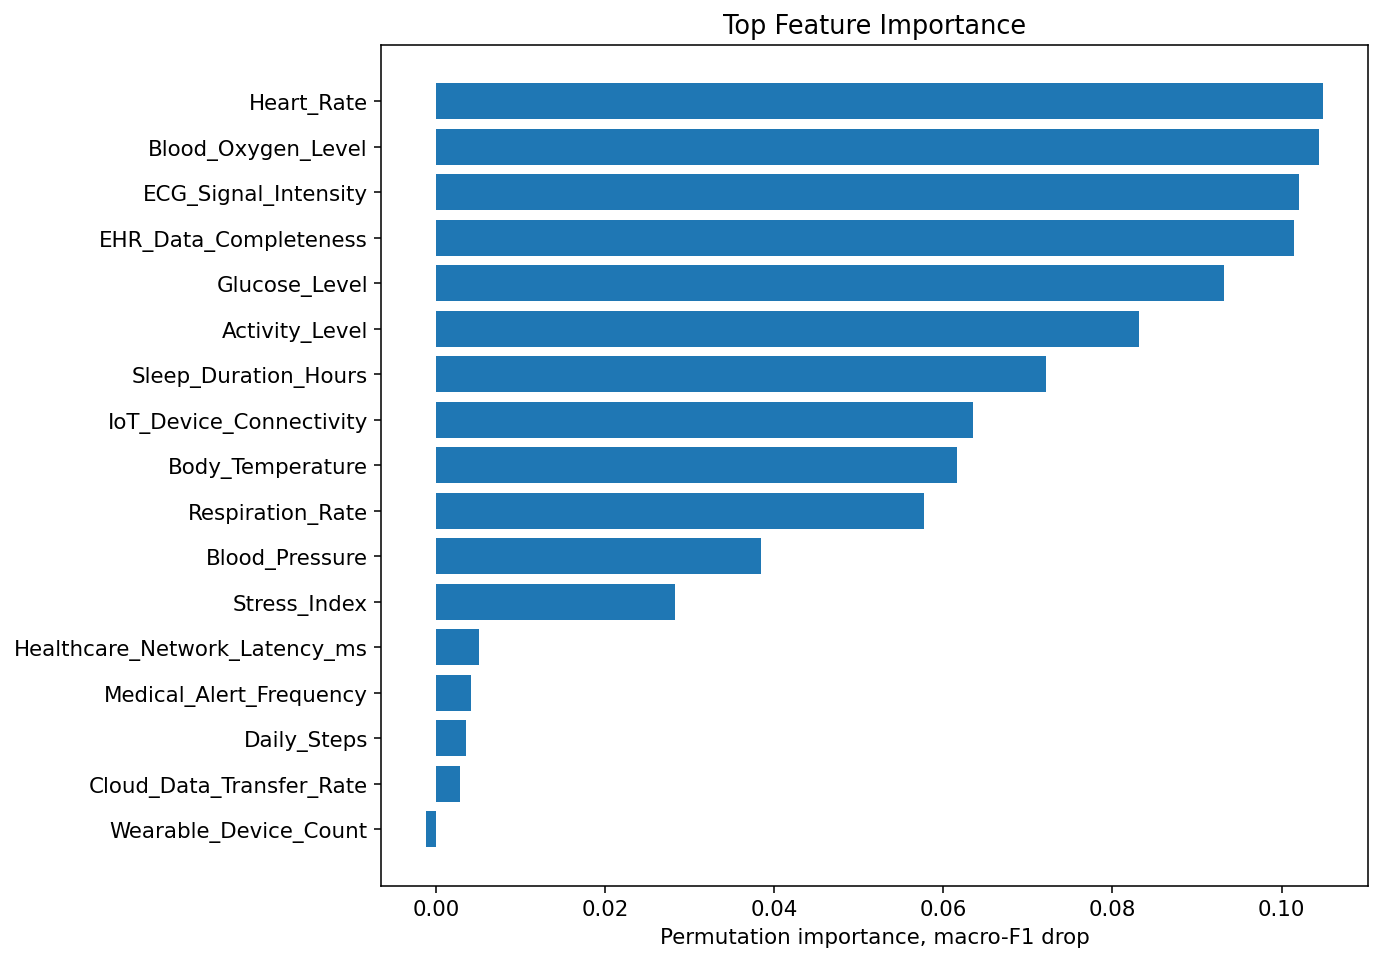

,Ablation,Features_Removed,Test_Macro_F1,Performance_Drop
1,Without Physiological,"Heart_Rate, Blood_Pressure, Blood_Oxygen_Level...",0.575970,0.235296
2,Without Behavioral,"Activity_Level, Sleep_Duration_Hours, Stress_I...",0.768739,0.042528
3,Without IoT_Data_Quality,"IoT_Device_Connectivity, EHR_Data_Completeness...",0.794888,0.016378
0,Full model,None,0.811267,0.000000
5,Without Alert,Medical_Alert_Frequency,0.814894,-0.003628
4,Without Network_Cloud,"Healthcare_Network_Latency_ms, Cloud_Data_Tran...",0.815201,-0.003934


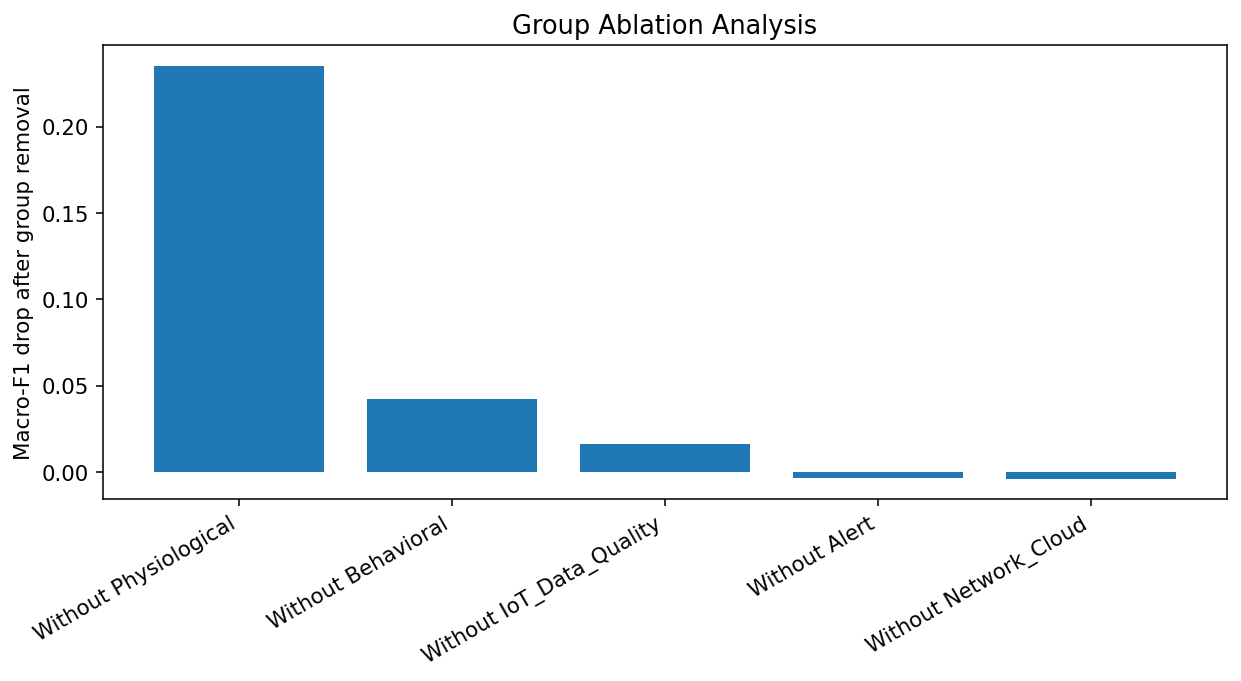

In [14]:
# ============================================================
# 13. Explainability: permutation importance and group ablation
# ============================================================

# Select the strongest fitted scikit model when available for model-agnostic explainability.
# If the best clean model is the hybrid model, use stacking if available; otherwise soft voting.
if best_clean["Model"] == "OGA-XAI-HIoT++_Stacking":
    explanation_model = stacking
    explanation_cols = cols_final
    explanation_name = "OGA-XAI-HIoT++_Stacking"
elif best_clean["Model"] == "OGA-XAI-HIoT++_SoftVoting":
    explanation_model = soft_voting
    explanation_cols = cols_final
    explanation_name = "OGA-XAI-HIoT++_SoftVoting"
else:
    key_matches = [k for k in trained_models if k[0] == best_clean["Model"] and k[1] == best_clean["Feature_Space"]]
    if key_matches:
        explanation_model = trained_models[key_matches[0]]
        explanation_cols = feature_spaces[best_clean["Feature_Space"]]
        explanation_name = best_clean["Model"]
    else:
        explanation_model = None
        explanation_cols = ALL_FEATURES
        explanation_name = "OGA-XAI-HIoT"

if explanation_model is not None:
    print("Running permutation importance for:", explanation_name)
    perm = permutation_importance(
        explanation_model,
        X_test_all[explanation_cols],
        y_test,
        scoring="f1_macro",
        n_repeats=10,
        random_state=SEED,
        n_jobs=-1
    )
    perm_df = pd.DataFrame({
        "Feature": explanation_cols,
        "Permutation_Importance_Mean": perm.importances_mean,
        "Permutation_Importance_Std": perm.importances_std
    }).sort_values("Permutation_Importance_Mean", ascending=False)
    perm_df.to_csv(TABLE_DIR / "17_permutation_feature_importance.csv", index=False)
    display(perm_df.head(20))

    plt.figure(figsize=(10, 7))
    top = perm_df.head(20).iloc[::-1]
    plt.barh(top["Feature"], top["Permutation_Importance_Mean"])
    plt.xlabel("Permutation importance, macro-F1 drop")
    plt.title("Top Feature Importance")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "Figure_8_Permutation_Feature_Importance.png", bbox_inches="tight")
    plt.show()
else:
    print("Permutation importance skipped because the selected model is a PyTorch model only.")

# Group ablation using the strongest easy-to-refit model from validation: HistGradientBoosting or ExtraTrees.
ablation_base = HistGradientBoostingClassifier(max_iter=700, learning_rate=0.025, l2_regularization=0.01, max_leaf_nodes=31, random_state=SEED)
ablation_rows = []
all_groups_cols = [c for group_cols in GROUPS.values() for c in group_cols]
base_cols = [c for c in ALL_FEATURES if c in all_groups_cols]

# Full group model.
base_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", ablation_base)])
base_pipe.fit(pd.concat([X_train_all[base_cols], X_val_all[base_cols]], axis=0), y_trainval_final)
full_pred = base_pipe.predict(X_test_all[base_cols])
full_f1 = f1_score(y_test, full_pred, average="macro", zero_division=0)
ablation_rows.append({"Ablation": "Full model", "Features_Removed": "None", "Test_Macro_F1": full_f1, "Performance_Drop": 0.0})

for group_name, remove_cols in GROUPS.items():
    remaining_cols = [c for c in base_cols if c not in remove_cols]
    pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", HistGradientBoostingClassifier(max_iter=700, learning_rate=0.025, l2_regularization=0.01, max_leaf_nodes=31, random_state=SEED))])
    pipe.fit(pd.concat([X_train_all[remaining_cols], X_val_all[remaining_cols]], axis=0), y_trainval_final)
    pred = pipe.predict(X_test_all[remaining_cols])
    f1 = f1_score(y_test, pred, average="macro", zero_division=0)
    ablation_rows.append({
        "Ablation": f"Without {group_name}",
        "Features_Removed": ", ".join(remove_cols),
        "Test_Macro_F1": f1,
        "Performance_Drop": full_f1 - f1
    })

ablation_df = pd.DataFrame(ablation_rows).sort_values("Performance_Drop", ascending=False)
ablation_df.to_csv(TABLE_DIR / "18_group_ablation_analysis.csv", index=False)
display(ablation_df)

plt.figure(figsize=(9, 5))
plot_ab = ablation_df[ablation_df["Ablation"] != "Full model"]
plt.bar(plot_ab["Ablation"], plot_ab["Performance_Drop"])
plt.ylabel("Macro-F1 drop after group removal")
plt.title("Group Ablation Analysis")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_9_Group_Ablation_Analysis.png", bbox_inches="tight")
plt.show()

,Group,Mean_CLS_Attention,Normalized_Attention
0,Physiological,0.492024,0.539431
2,IoT_Data_Quality,0.172933,0.189595
1,Behavioral,0.149708,0.164133
3,Network_Cloud,0.079143,0.086769
4,Alert,0.018308,0.020072


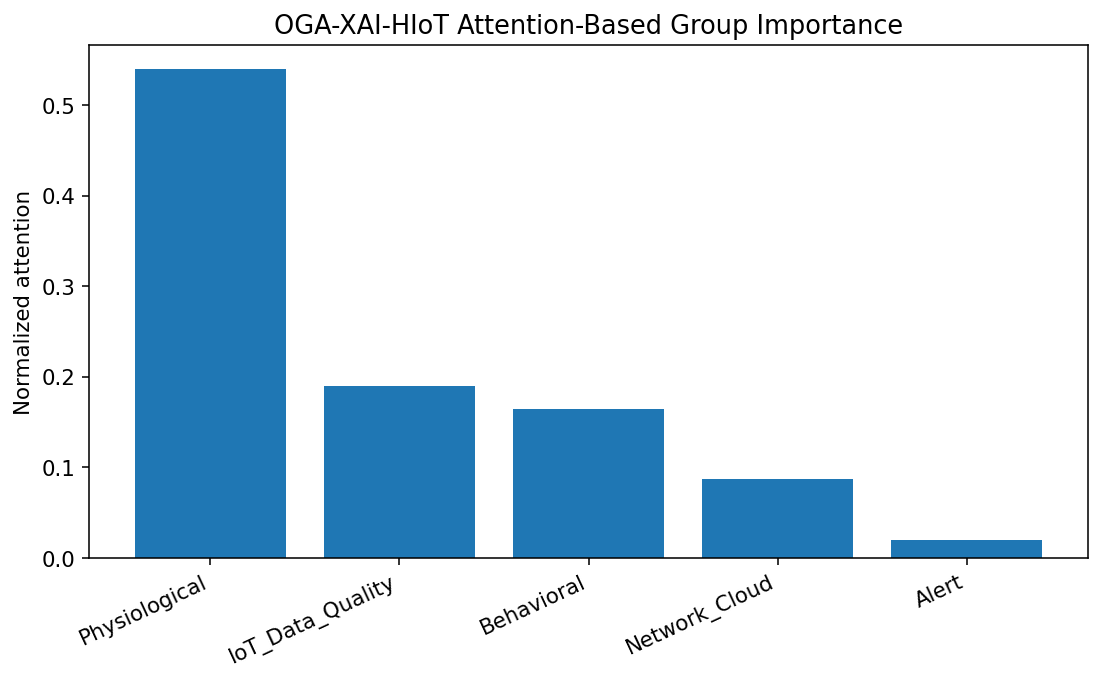

In [15]:
# ============================================================
# 14. OGA attention group importance
# ============================================================

# Attention tensor shape is usually [batch, target_tokens, source_tokens].
# Token 0 is the CLS token, and group tokens start at index 1.
try:
    attn = best_oga["attention"]
    group_names = list(GROUPS.keys())
    if attn.ndim == 3 and attn.shape[-1] == len(group_names) + 1:
        cls_to_groups = attn[:, 0, 1:]
        group_attention = cls_to_groups.mean(axis=0)
        attention_df = pd.DataFrame({
            "Group": group_names,
            "Mean_CLS_Attention": group_attention,
            "Normalized_Attention": group_attention / np.sum(group_attention)
        }).sort_values("Normalized_Attention", ascending=False)
        attention_df.to_csv(TABLE_DIR / "19_oga_attention_group_importance.csv", index=False)
        display(attention_df)

        plt.figure(figsize=(8, 5))
        plt.bar(attention_df["Group"], attention_df["Normalized_Attention"])
        plt.ylabel("Normalized attention")
        plt.title("OGA-XAI-HIoT Attention-Based Group Importance")
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "Figure_10_OGA_Attention_Group_Importance.png", bbox_inches="tight")
        plt.show()
    else:
        print("Attention shape not suitable for group summary:", attn.shape)
except Exception as e:
    print("Attention extraction skipped:", e)

,Model,Feature_Space,Test_Accuracy,Test_Balanced_Accuracy,Test_Macro_Precision,Test_Macro_Recall,Test_Macro_F1,Test_Weighted_F1,MCC,Cohen_Kappa,Multiclass_ROC_AUC,Brier_Score_Multiclass,Mean_Absolute_Ordinal_Error,Severe_Misclassification_Rate,Recall_Stable,Recall_Moderate_Risk,Recall_High_Risk,Recall_Critical
0,Calibrated_ExtraTrees,RAW,0.81375,0.813804,0.814054,0.813804,0.813682,0.81362,0.751819,0.751664,0.956077,0.2699,0.29625,0.07875,0.855,0.785,0.829146,0.78607


,Confidence_Lower,Confidence_Upper,Count,Mean_Confidence,Accuracy
0,0.3,0.4,10,0.360388,0.400000
1,0.4,0.5,34,0.456373,0.529412
2,0.5,0.6,104,0.549526,0.509615
3,0.6,0.7,93,0.647454,0.709677
4,0.7,0.8,106,0.752225,0.792453
5,0.8,0.9,127,0.852252,0.889764
6,0.9,1.0,326,0.963931,0.960123


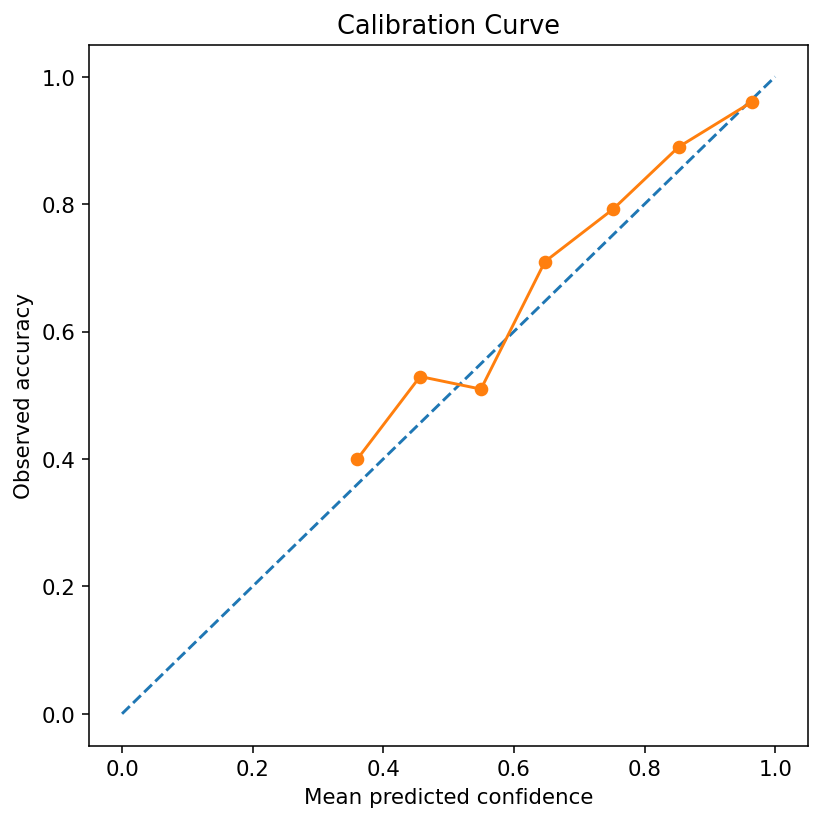

In [16]:
# ============================================================
# 15. Probability calibration and reliability check
# ============================================================

# Calibration is performed on a robust scikit model using train/validation only.
# This supports medical decision-support reporting.

calibration_base = ExtraTreesClassifier(
    n_estimators=1000, max_features="sqrt", class_weight="balanced", random_state=SEED, n_jobs=-1
)
calibrated_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("cal", CalibratedClassifierCV(calibration_base, method="isotonic", cv=5))
])

calibration_cols = RAW_FEATURES  # raw features often gave stronger stable tabular results.
calibrated_model.fit(X_trainval_all[calibration_cols], y_trainval)
cal_pred = calibrated_model.predict(X_test_all[calibration_cols])
cal_proba = calibrated_model.predict_proba(X_test_all[calibration_cols])
cal_row = evaluate_predictions("Calibrated_ExtraTrees", "RAW", y_test, cal_pred, cal_proba)
calibration_results = pd.DataFrame([cal_row])
calibration_results.to_csv(TABLE_DIR / "20_calibration_results.csv", index=False)
display(calibration_results)

# Reliability-style plot: confidence vs correctness by confidence bins.
conf = cal_proba.max(axis=1)
correct = (cal_pred == y_test.values).astype(int)
bins = np.linspace(0, 1, 11)
bin_rows = []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (conf >= lo) & (conf < hi if hi < 1 else conf <= hi)
    if mask.sum() > 0:
        bin_rows.append({
            "Confidence_Lower": lo,
            "Confidence_Upper": hi,
            "Count": int(mask.sum()),
            "Mean_Confidence": float(conf[mask].mean()),
            "Accuracy": float(correct[mask].mean())
        })
calibration_curve_df = pd.DataFrame(bin_rows)
calibration_curve_df.to_csv(TABLE_DIR / "21_calibration_curve_bins.csv", index=False)
display(calibration_curve_df)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--")
if not calibration_curve_df.empty:
    plt.plot(calibration_curve_df["Mean_Confidence"], calibration_curve_df["Accuracy"], marker="o")
plt.xlabel("Mean predicted confidence")
plt.ylabel("Observed accuracy")
plt.title("Calibration Curve")
plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_11_Calibration_Curve.png", bbox_inches="tight")
plt.show()

In [17]:
# ============================================================
# 16. Secondary dataset analyses for proposal completeness
# ============================================================

# RQ7: Sensor battery consumption analysis from healthcare_iot_target_dataset.csv.
battery_path = find_first_existing(SECONDARY_BATTERY_CANDIDATES)
if battery_path is not None:
    print("Battery/sensor secondary dataset found:", battery_path)
    df_bat = pd.read_csv(battery_path)
    required_bat = ["Sensor_Type", "Device_Battery_Level (%)", "Battery_Level (%)"]
    if all(c in df_bat.columns for c in required_bat):
        sensor_summary = df_bat.groupby("Sensor_Type").agg(
            Count=("Sensor_Type", "size"),
            Mean_Device_Battery=("Device_Battery_Level (%)", "mean"),
            Mean_Battery=("Battery_Level (%)", "mean"),
            Min_Battery=("Battery_Level (%)", "min"),
            Std_Battery=("Battery_Level (%)", "std"),
            Low_Battery_Percent=("Battery_Level (%)", lambda s: float((s < 85).mean() * 100))
        ).reset_index().sort_values("Mean_Battery")
        sensor_summary.to_csv(TABLE_DIR / "RQ7_sensor_battery_analysis.csv", index=False)
        display(sensor_summary)
        plt.figure(figsize=(8, 5))
        plt.bar(sensor_summary["Sensor_Type"], sensor_summary["Mean_Battery"])
        plt.ylabel("Mean observed battery level (%)")
        plt.title("Sensor Battery Summary by Sensor Type")
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "Figure_12_Sensor_Battery_By_Type.png", bbox_inches="tight")
        plt.show()
    else:
        pd.DataFrame([{"RQ": "RQ7", "Status": "Required battery columns not found."}]).to_csv(TABLE_DIR / "RQ7_sensor_battery_analysis_NOT_AVAILABLE.csv", index=False)
else:
    pd.DataFrame([{"RQ": "RQ7", "Status": "Secondary battery/sensor dataset not found in runtime."}]).to_csv(TABLE_DIR / "RQ7_sensor_battery_analysis_NOT_AVAILABLE.csv", index=False)
    print("RQ7 secondary battery/sensor dataset not found. Upload healthcare_iot_target_dataset.csv to answer RQ7 empirically.")

# RQ4: true timestamp fluctuation from Multi-Sensor Medical IoT dataset.
time_path = find_first_existing(SECONDARY_TIME_CANDIDATES)
if time_path is not None:
    print("Timestamp secondary dataset found:", time_path)
    df_time = pd.read_csv(time_path)
    if "timestamp" in df_time.columns:
        df_time["timestamp"] = pd.to_datetime(df_time["timestamp"], errors="coerce")
    numeric_time_cols = [c for c in df_time.select_dtypes(include=np.number).columns if c not in ["latitude", "longitude"]]
    fluct_rows = []
    for col in numeric_time_cols:
        vals = df_time[col].dropna()
        if len(vals) == 0:
            continue
        mean_val = vals.mean()
        std_val = vals.std()
        cv = std_val / mean_val if abs(mean_val) > 1e-12 else np.nan
        fluct_rows.append({"Feature": col, "Mean": mean_val, "Std": std_val, "Coefficient_of_Variation": cv})
    fluct_df = pd.DataFrame(fluct_rows).sort_values("Coefficient_of_Variation", ascending=False)
    fluct_df.to_csv(TABLE_DIR / "RQ4_time_fluctuation_secondary_dataset.csv", index=False)
    display(fluct_df.head(20))
    if "timestamp" in df_time.columns and not df_time["timestamp"].isna().all():
        for col in ["heart_rate", "spo2_level", "body_temperature", "blood_glucose"]:
            if col in df_time.columns:
                tmp = df_time.sort_values("timestamp")
                plt.figure(figsize=(10, 4))
                plt.plot(tmp["timestamp"], tmp[col], linewidth=1)
                plt.title(f"{col} over time")
                plt.xlabel("Timestamp")
                plt.ylabel(col)
                plt.xticks(rotation=25)
                plt.tight_layout()
                plt.savefig(FIG_DIR / f"Figure_Time_{col}_Trend.png", bbox_inches="tight")
                plt.show()
else:
    pd.DataFrame([{"RQ": "RQ4", "Status": "Secondary timestamp dataset not found in runtime."}]).to_csv(TABLE_DIR / "RQ4_time_fluctuation_secondary_NOT_AVAILABLE.csv", index=False)
    print("RQ4 secondary timestamp dataset not found. Upload Multi-Sensor_Medical_IoT_Dataset.csv to answer true time-based fluctuation empirically.")

RQ7 secondary battery/sensor dataset not found. Upload healthcare_iot_target_dataset.csv to answer RQ7 empirically.
RQ4 secondary timestamp dataset not found. Upload Multi-Sensor_Medical_IoT_Dataset.csv to answer true time-based fluctuation empirically.


In [18]:
# ============================================================
# 17. RQ-wise final output mapping
# ============================================================

rq_rows = [
    {
        "RQ": "RQ1",
        "Research_Question": "Which physiological, behavioral, and IoT-system factors have the strongest impact on patient health-status classification?",
        "Dataset": "Primary digital ecosystem dataset",
        "Analysis": "Permutation importance, group ablation, OGA attention importance",
        "Output_File": "17_permutation_feature_importance.csv; 18_group_ablation_analysis.csv; 19_oga_attention_group_importance.csv",
        "Status": "Completed"
    },
    {
        "RQ": "RQ2",
        "Research_Question": "Which activity patterns are associated with healthier or riskier patient conditions?",
        "Dataset": "Primary digital ecosystem dataset",
        "Analysis": "Activity, steps, sleep, and stress profile by health-status class",
        "Output_File": "06_activity_health_profile.csv",
        "Status": "Completed"
    },
    {
        "RQ": "RQ3",
        "Research_Question": "Are there any health-monitoring factors that remain consistently high or low across the datasets?",
        "Dataset": "Primary digital ecosystem dataset",
        "Analysis": "Descriptive statistics, coefficient of variation, outlier analysis",
        "Output_File": "05_high_low_consistency_analysis.csv",
        "Status": "Completed for primary dataset"
    },
    {
        "RQ": "RQ4",
        "Research_Question": "Which physiological or sensor-based factors fluctuate most over time?",
        "Dataset": "Secondary multi-sensor timestamp dataset",
        "Analysis": "Timestamp trend and coefficient-of-variation analysis",
        "Output_File": "RQ4_time_fluctuation_secondary_dataset.csv or NOT_AVAILABLE file",
        "Status": "Completed if secondary dataset is uploaded"
    },
    {
        "RQ": "RQ5",
        "Research_Question": "How do IoT-system variables affect healthcare monitoring outcomes?",
        "Dataset": "Primary digital ecosystem dataset",
        "Analysis": "IoT connectivity, EHR completeness, wearable count, latency, transfer rate, alerts by status",
        "Output_File": "07_iot_network_status_summary.csv",
        "Status": "Completed"
    },
    {
        "RQ": "RQ6",
        "Research_Question": "Is there evidence of significant delay in healthcare IoT monitoring?",
        "Dataset": "Primary digital ecosystem dataset",
        "Analysis": "Network latency and cloud transfer rate used as proxy indicators only",
        "Output_File": "07_iot_network_status_summary.csv",
        "Status": "Completed as proxy; no direct timestamp delay claim"
    },
    {
        "RQ": "RQ7",
        "Research_Question": "Which type of sensor consumes more battery power in healthcare IoT monitoring?",
        "Dataset": "Secondary healthcare IoT target dataset",
        "Analysis": "Battery level grouped by Sensor_Type",
        "Output_File": "RQ7_sensor_battery_analysis.csv or NOT_AVAILABLE file",
        "Status": "Completed if secondary dataset is uploaded"
    },
    {
        "RQ": "RQ8",
        "Research_Question": "Which machine-learning model provides the best baseline performance for predicting patient health status?",
        "Dataset": "Primary digital ecosystem dataset",
        "Analysis": "Baseline vs strong tabular vs OGA-XAI-HIoT vs hybrid OGA-XAI-HIoT++ comparison",
        "Output_File": "14_FINAL_model_performance_comparison.csv",
        "Status": "Completed"
    },
    {
        "RQ": "RQ9",
        "Research_Question": "What comfort, compatibility, power-source, and deployment challenges remain?",
        "Dataset": "Literature-based discussion",
        "Analysis": "Discuss based on uploaded literature; do not claim from dataset variables",
        "Output_File": "RQ9_literature_discussion_required.txt",
        "Status": "Requires manuscript discussion, not direct dataset result"
    },
]

rq_df = pd.DataFrame(rq_rows)
rq_df.to_csv(TABLE_DIR / "22_RQ_wise_final_summary.csv", index=False)
display(rq_df)

with open(TABLE_DIR / "RQ9_literature_discussion_required.txt", "w") as f:
    f.write(
        "RQ9 is literature-based. The primary dataset does not contain patient comfort, device weight, "
        "wearing duration, charging frequency, rural power availability, patient feedback, or compatibility variables. "
        "Discuss these limitations using the uploaded literature and do not report them as empirical dataset findings."
    )

,RQ,Research_Question,Dataset,Analysis,Output_File,Status
0,RQ1,"Which physiological, behavioral, and IoT-syste...",Primary digital ecosystem dataset,"Permutation importance, group ablation, OGA at...",17_permutation_feature_importance.csv; 18_grou...,Completed
1,RQ2,Which activity patterns are associated with he...,Primary digital ecosystem dataset,"Activity, steps, sleep, and stress profile by ...",06_activity_health_profile.csv,Completed
2,RQ3,Are there any health-monitoring factors that r...,Primary digital ecosystem dataset,"Descriptive statistics, coefficient of variati...",05_high_low_consistency_analysis.csv,Completed for primary dataset
3,RQ4,Which physiological or sensor-based factors fl...,Secondary multi-sensor timestamp dataset,Timestamp trend and coefficient-of-variation a...,RQ4_time_fluctuation_secondary_dataset.csv or ...,Completed if secondary dataset is uploaded
4,RQ5,How do IoT-system variables affect healthcare ...,Primary digital ecosystem dataset,"IoT connectivity, EHR completeness, wearable c...",07_iot_network_status_summary.csv,Completed
5,RQ6,Is there evidence of significant delay in heal...,Primary digital ecosystem dataset,Network latency and cloud transfer rate used a...,07_iot_network_status_summary.csv,Completed as proxy; no direct timestamp delay ...
6,RQ7,Which type of sensor consumes more battery pow...,Secondary healthcare IoT target dataset,Battery level grouped by Sensor_Type,RQ7_sensor_battery_analysis.csv or NOT_AVAILAB...,Completed if secondary dataset is uploaded
7,RQ8,Which machine-learning model provides the best...,Primary digital ecosystem dataset,Baseline vs strong tabular vs OGA-XAI-HIoT vs ...,14_FINAL_model_performance_comparison.csv,Completed
8,RQ9,"What comfort, compatibility, power-source, and...",Literature-based discussion,Discuss based on uploaded literature; do not c...,RQ9_literature_discussion_required.txt,"Requires manuscript discussion, not direct dat..."


In [19]:
# ============================================================
# 18. Final export summary
# ============================================================

print("=" * 100)
print("FINAL NOTEBOOK COMPLETED")
print("=" * 100)
print("Tables saved to:", TABLE_DIR)
print("Figures saved to:", FIG_DIR)

print("\nMost important output files:")
important_files = [
    "14_FINAL_model_performance_comparison.csv",
    "16_label_separability_and_99pct_validity_audit.csv",
    "17_permutation_feature_importance.csv",
    "18_group_ablation_analysis.csv",
    "19_oga_attention_group_importance.csv",
    "22_RQ_wise_final_summary.csv"
]
for fname in important_files:
    fpath = TABLE_DIR / fname
    print(fname, "->", "FOUND" if fpath.exists() else "MISSING")

print("\nFinal scientific reporting rule:")
print("Report the best leakage-free model from 14_FINAL_model_performance_comparison.csv.")
print("If the best accuracy is below 99%, do not force 99%. Discuss label separability and report the clean result.")
print("Use OGA-XAI-HIoT for explainable group-attention contribution and OGA-XAI-HIoT++ as the hybrid prediction framework.")

# Optional: zip all outputs for download in Colab.
try:
    import shutil
    zip_path = shutil.make_archive(str(BASE_DIR), "zip", str(BASE_DIR))
    print("Output ZIP created:", zip_path)
except Exception as e:
    print("Could not create ZIP:", e)

FINAL NOTEBOOK COMPLETED
Tables saved to: /content/OGA_XAI_HIoT_FINAL_OUTPUTS/tables
Figures saved to: /content/OGA_XAI_HIoT_FINAL_OUTPUTS/figures

Most important output files:
14_FINAL_model_performance_comparison.csv -> FOUND
16_label_separability_and_99pct_validity_audit.csv -> FOUND
17_permutation_feature_importance.csv -> FOUND
18_group_ablation_analysis.csv -> FOUND
19_oga_attention_group_importance.csv -> FOUND
22_RQ_wise_final_summary.csv -> FOUND

Final scientific reporting rule:
Report the best leakage-free model from 14_FINAL_model_performance_comparison.csv.
If the best accuracy is below 99%, do not force 99%. Discuss label separability and report the clean result.
Use OGA-XAI-HIoT for explainable group-attention contribution and OGA-XAI-HIoT++ as the hybrid prediction framework.
Output ZIP created: /content/OGA_XAI_HIoT_FINAL_OUTPUTS.zip
